Cargando ANTES (CSV)...
Cargando DESPUÉS (NPY)...
Datos listos. Generando figuras...



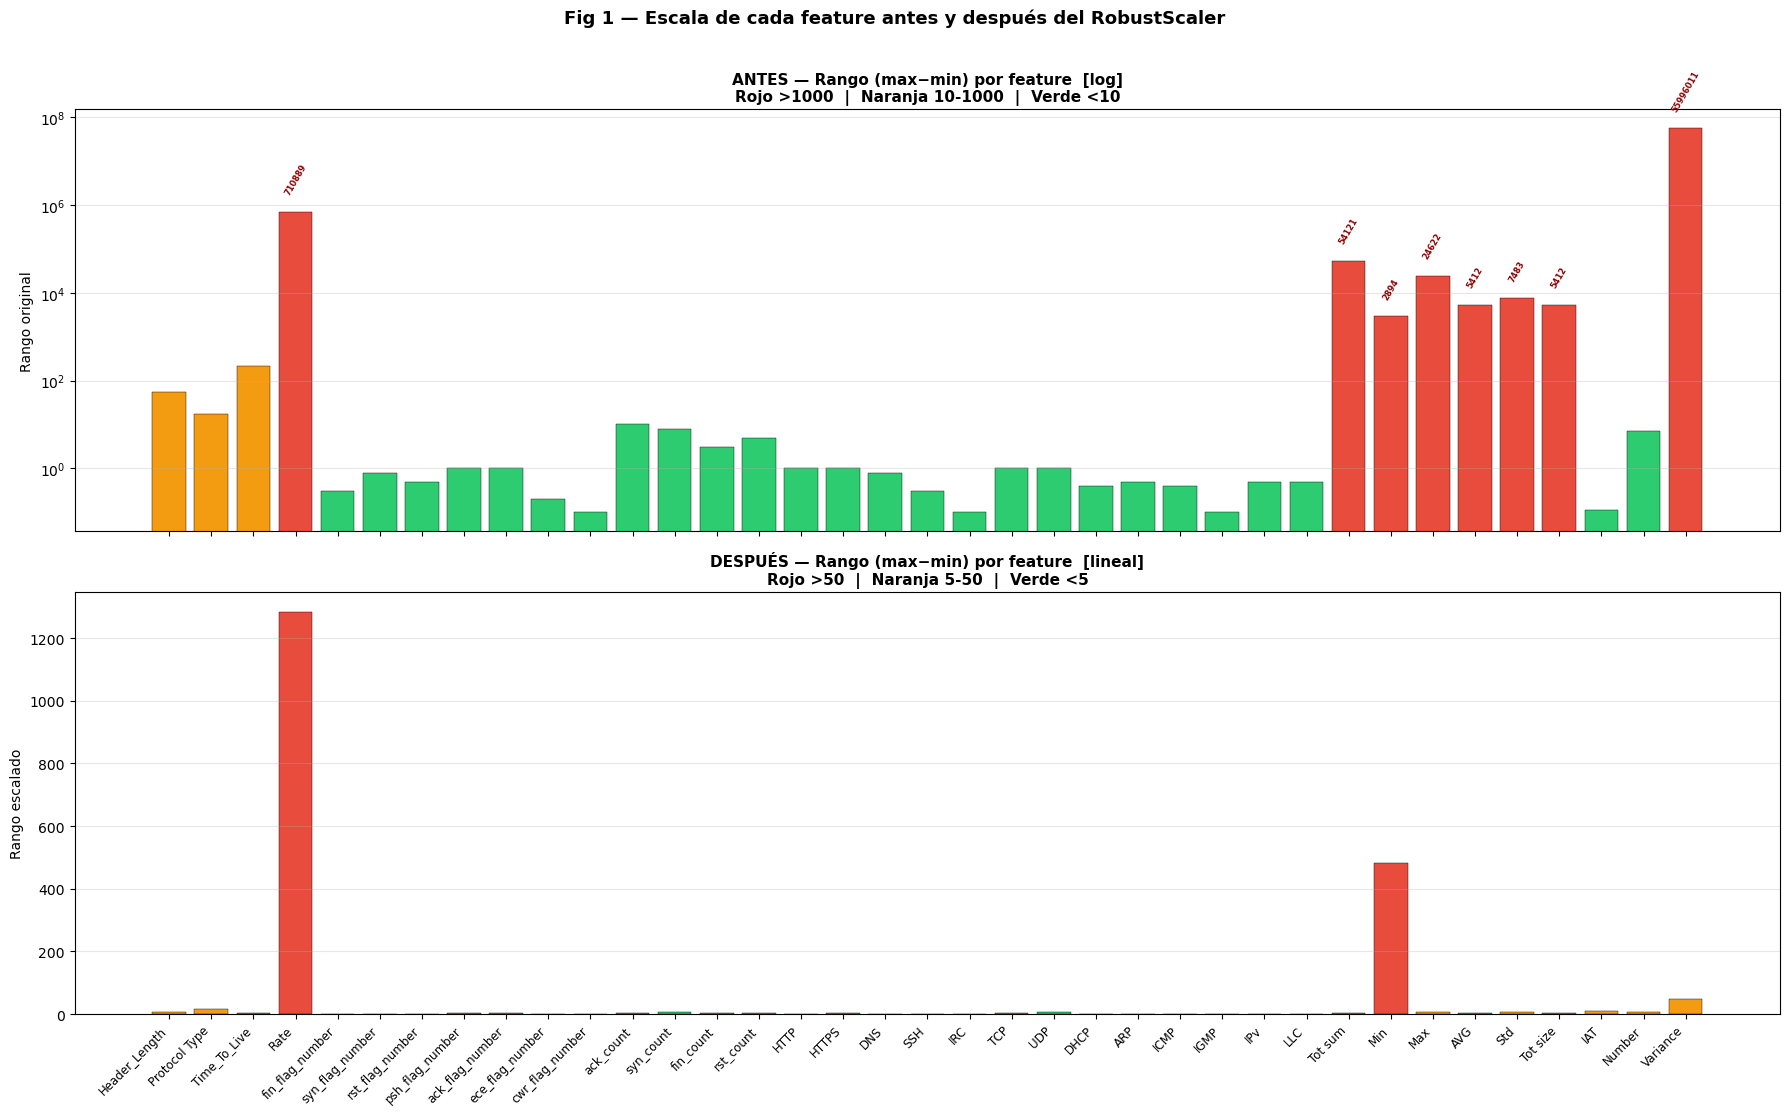

✓ fig1_rangos.png



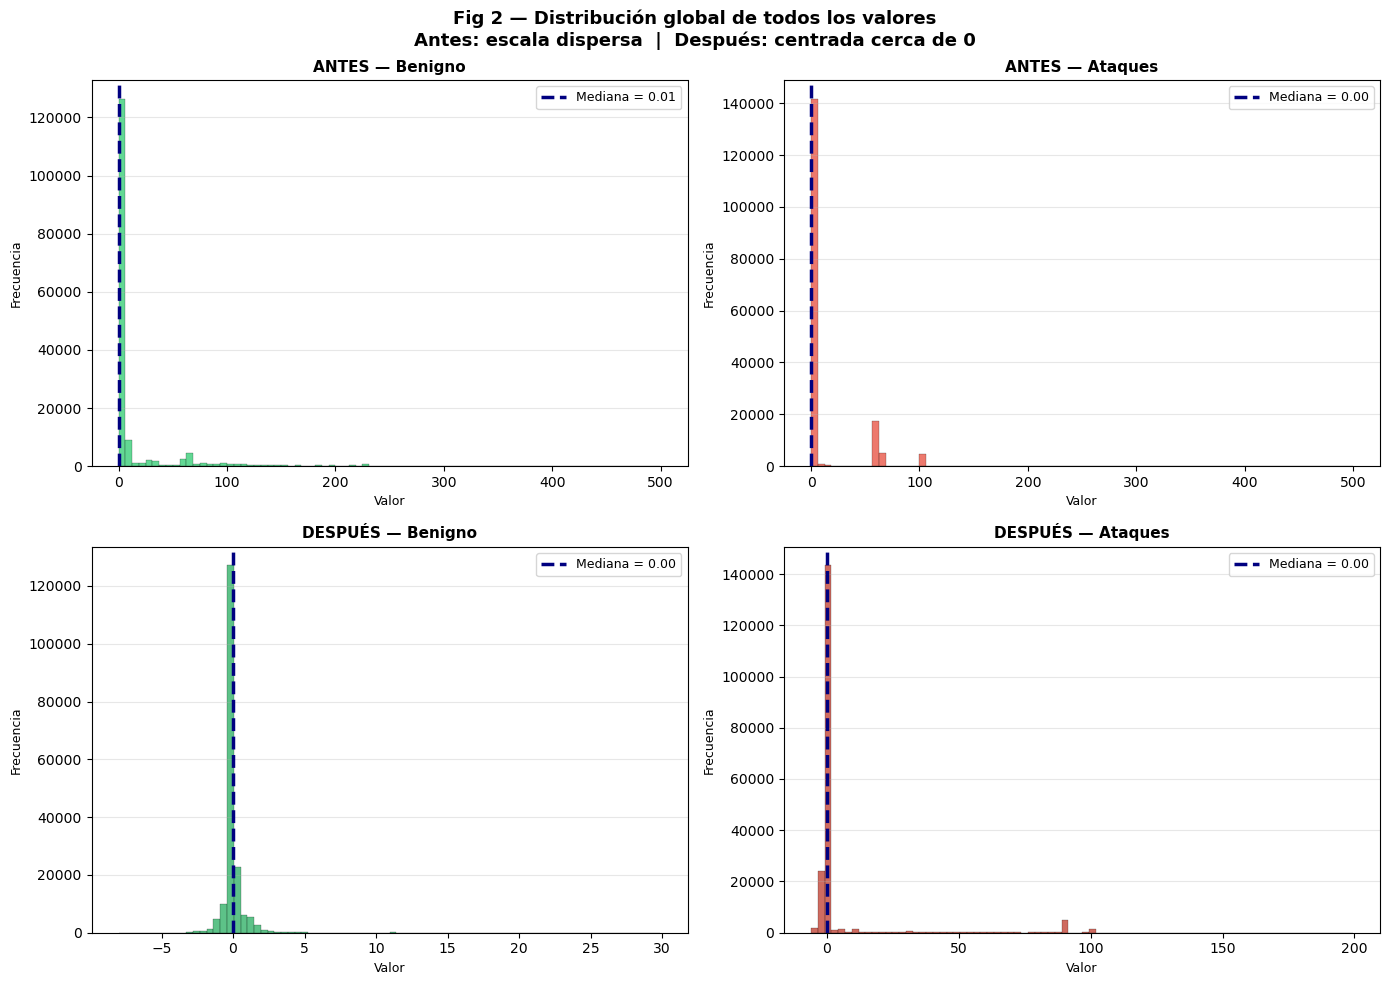

✓ fig2_distribucion_global.png



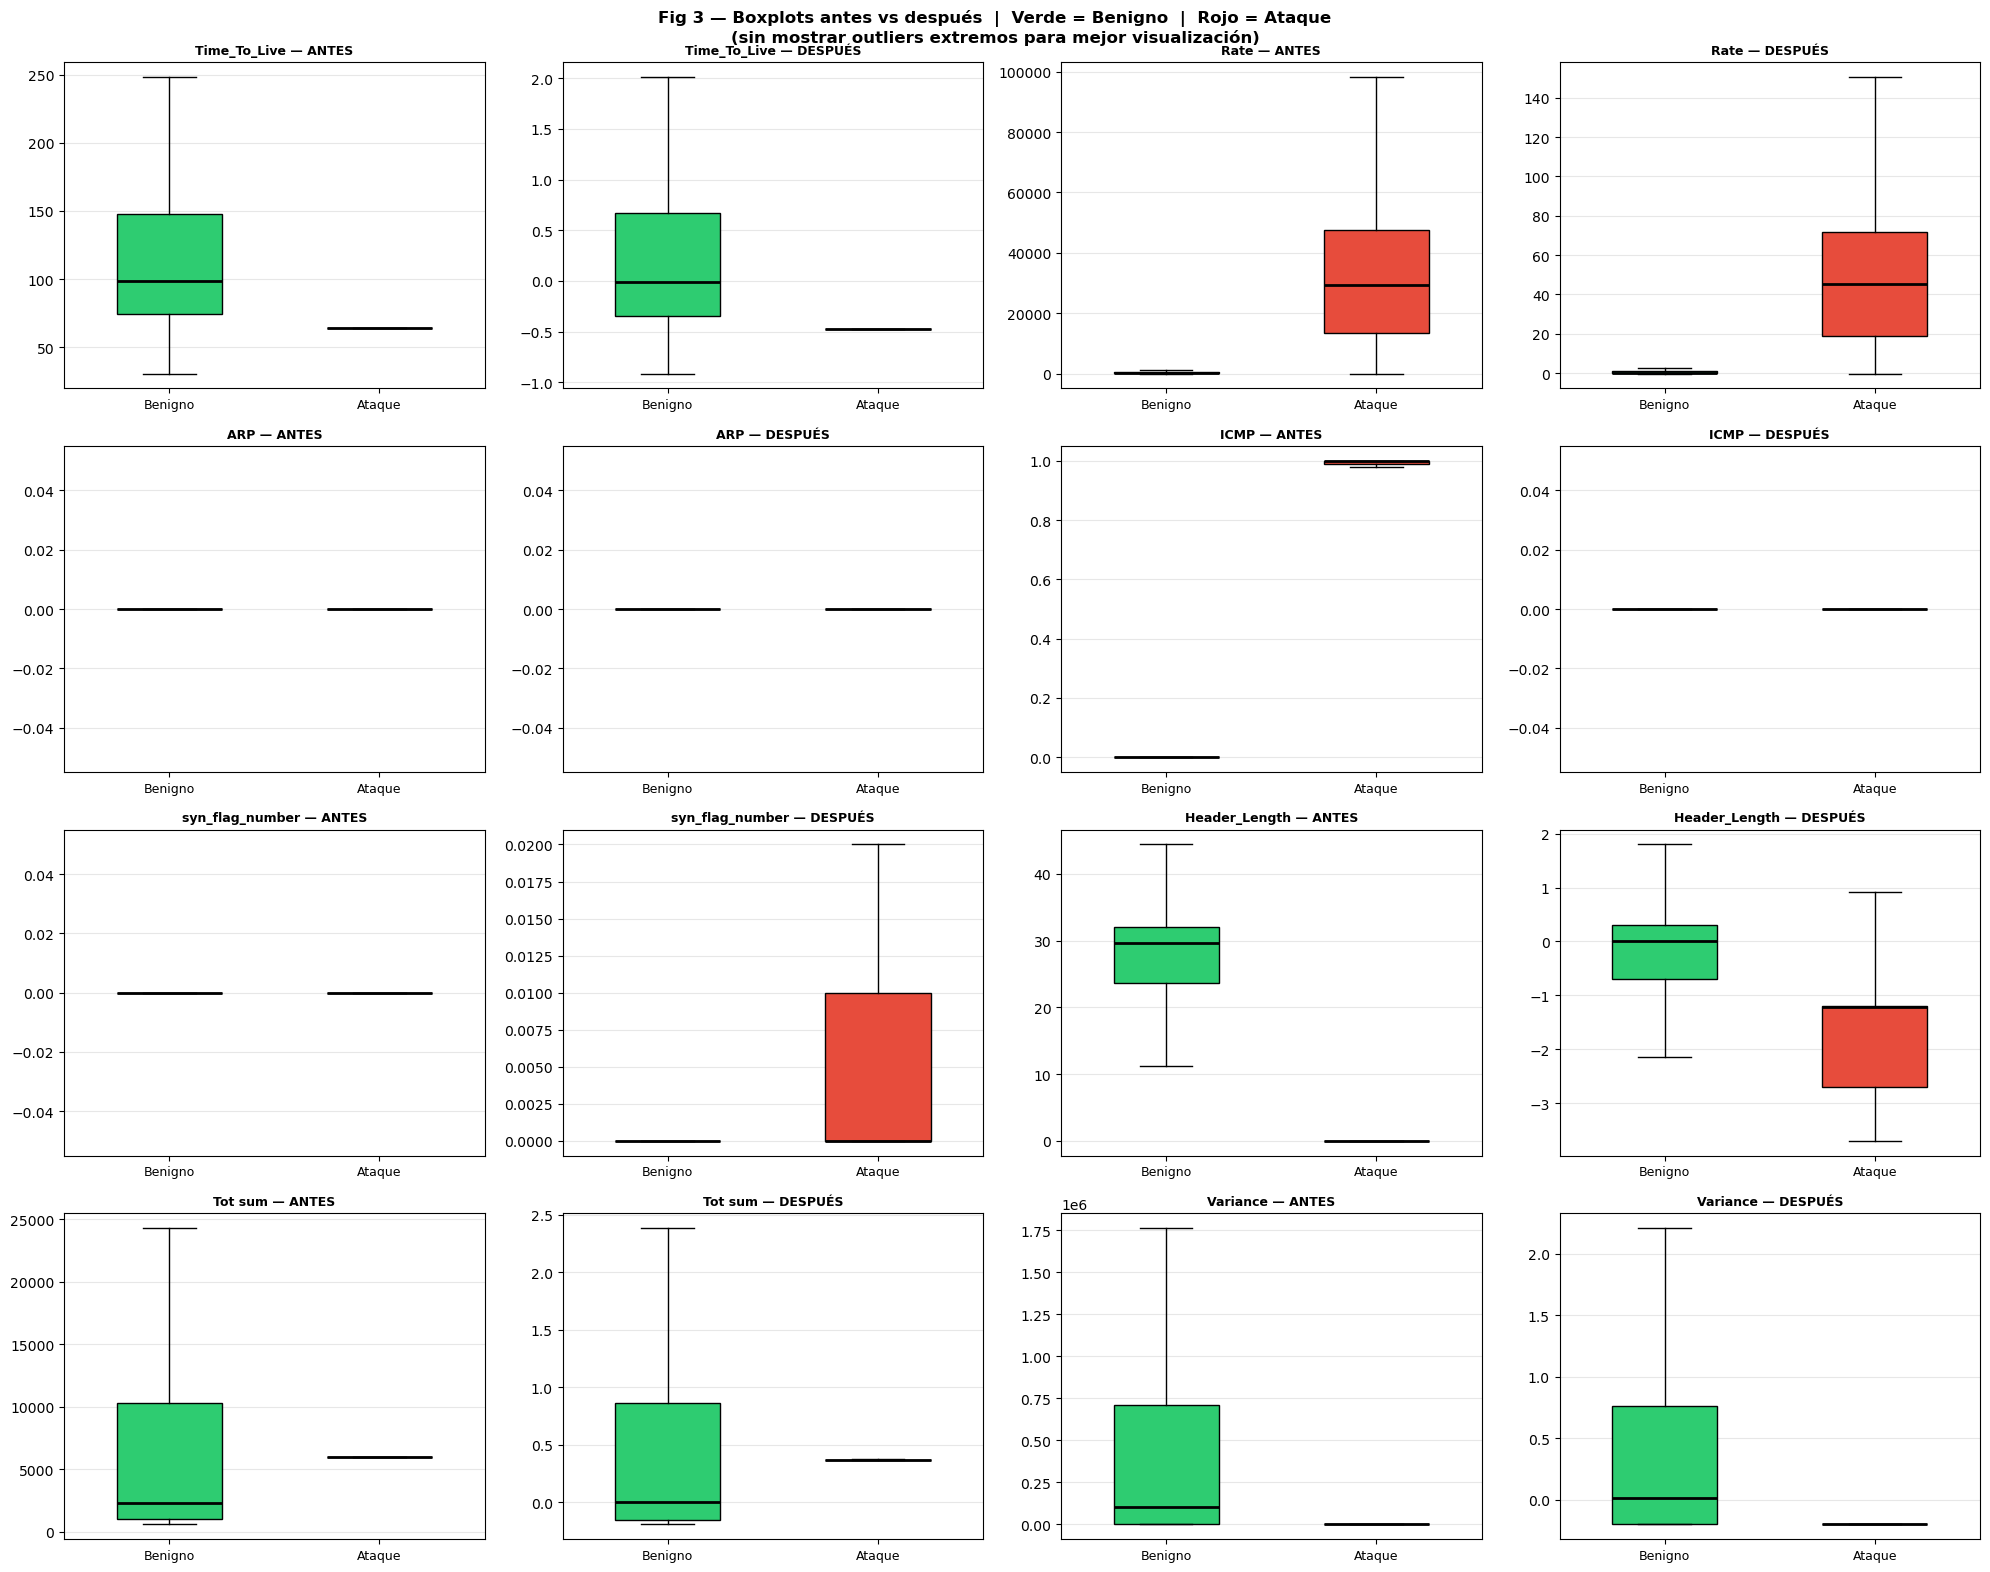

✓ fig3_boxplots.png



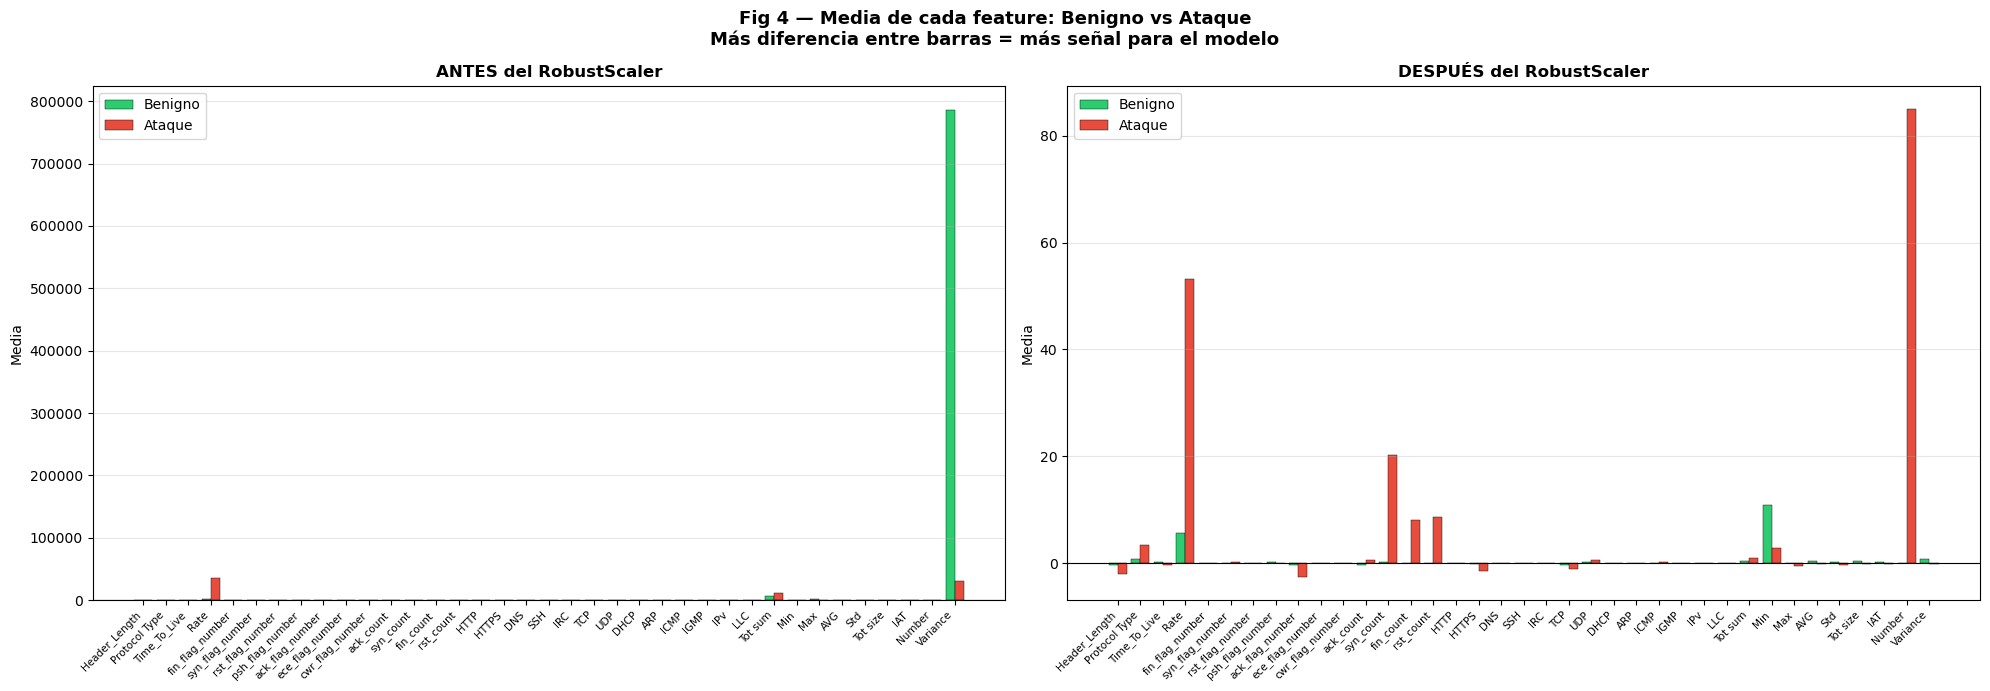

✓ fig4_separabilidad.png



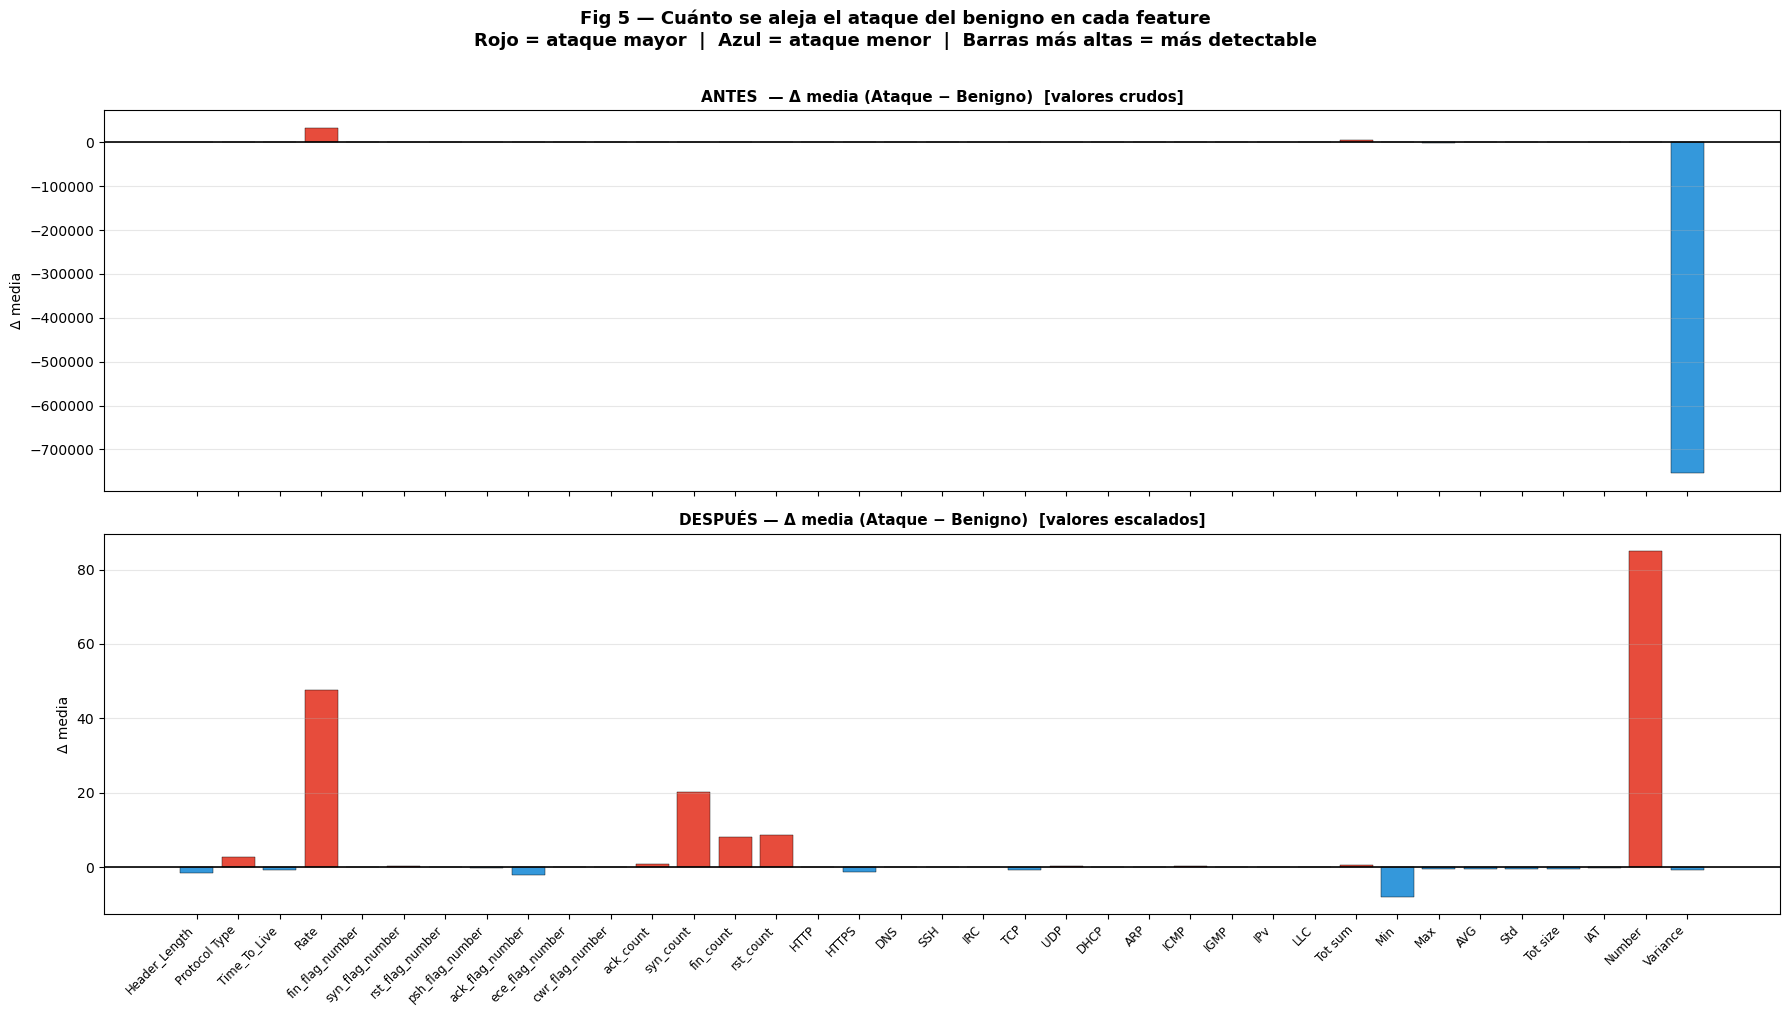

✓ fig5_diferencia_medias.png

  Todas las gráficas guardadas en:
  C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\graficas_comparativa


In [1]:
# ── COMPARATIVA ANTES vs DESPUÉS DEL ROBUSTSCALER ────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════
# CONFIGURACIÓN
# ════════════════════════════════════════════════════════════════
BASE     = Path(r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz")
PART_DIR = BASE / "particiones"
NORM_DIR = BASE / "normalizacion"
GRAF_DIR = BASE / "graficas_comparativa"
GRAF_DIR.mkdir(exist_ok=True)

FEATURES = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'SSH', 'IRC',
    'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

N = 5000
np.random.seed(42)

# ════════════════════════════════════════════════════════════════
# CARGAR DATOS
# ════════════════════════════════════════════════════════════════
print("Cargando ANTES (CSV)...")
ben_raw = (pd.read_csv(PART_DIR / "benign_train_80.csv",
                        usecols=FEATURES, nrows=30000)
             .sample(N, random_state=42).reset_index(drop=True))

df_tmp  = pd.read_csv(PART_DIR / "attack_test.csv", nrows=30000)
atk_raw = df_tmp[FEATURES].sample(N, random_state=42).reset_index(drop=True)
del df_tmp

print("Cargando DESPUÉS (NPY)...")
arr = np.load(NORM_DIR / "train_norm.npy")
ben_norm = pd.DataFrame(
    arr[np.random.choice(len(arr), N, replace=False)], columns=FEATURES)
del arr

arr = np.load(NORM_DIR / "atk_norm.npy")
atk_norm = pd.DataFrame(
    arr[np.random.choice(len(arr), N, replace=False)], columns=FEATURES)
del arr

print("Datos listos. Generando figuras...\n")

# ════════════════════════════════════════════════════════════════
# FIGURA 1 — RANGO (max-min) POR FEATURE
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(18, 11), sharex=True)

rangos_a = (ben_raw.max()  - ben_raw.min()).clip(lower=0.01)
rangos_d = (ben_norm.max() - ben_norm.min()).clip(lower=0.01)

col_a = ['#e74c3c' if v > 1000 else '#f39c12' if v > 10 else '#2ecc71'
          for v in rangos_a]
col_d = ['#e74c3c' if v > 50 else '#f39c12' if v > 5 else '#2ecc71'
          for v in rangos_d]

axes[0].bar(range(len(FEATURES)), rangos_a.values, color=col_a,
            edgecolor='black', linewidth=0.3)
axes[0].set_yscale('log')
axes[0].set_title('ANTES — Rango (max−min) por feature  [log]\n'
                   'Rojo >1000  |  Naranja 10-1000  |  Verde <10',
                   fontsize=11, fontweight='bold')
axes[0].set_ylabel('Rango original', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(rangos_a.values):
    if v > 500:
        axes[0].text(i, v*2.5, f'{v:.0f}', ha='center', fontsize=6,
                      rotation=60, color='darkred', fontweight='bold')

axes[1].bar(range(len(FEATURES)), rangos_d.values, color=col_d,
            edgecolor='black', linewidth=0.3)
axes[1].set_xticks(range(len(FEATURES)))
axes[1].set_xticklabels(FEATURES, rotation=45, ha='right', fontsize=8.5)
axes[1].set_title('DESPUÉS — Rango (max−min) por feature  [lineal]\n'
                   'Rojo >50  |  Naranja 5-50  |  Verde <5',
                   fontsize=11, fontweight='bold')
axes[1].set_ylabel('Rango escalado', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Fig 1 — Escala de cada feature antes y después del RobustScaler',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(GRAF_DIR / 'fig1_rangos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig1_rangos.png\n")

# ════════════════════════════════════════════════════════════════
# FIGURA 2 — DISTRIBUCIÓN GLOBAL DE TODOS LOS VALORES
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

configs = [
    (ben_raw.values.flatten(),  axes[0,0], 'ANTES — Benigno',  '#2ecc71', (-5, 500)),
    (atk_raw.values.flatten(),  axes[0,1], 'ANTES — Ataques',  '#e74c3c', (-5, 500)),
    (ben_norm.values.flatten(), axes[1,0], 'DESPUÉS — Benigno','#27ae60', (-10, 30)),
    (atk_norm.values.flatten(), axes[1,1], 'DESPUÉS — Ataques','#c0392b', (-10, 200)),
]

for vals, ax, titulo, color, xlim in configs:
    v = vals[np.isfinite(vals)]
    v = v[(v >= xlim[0]) & (v <= xlim[1])]
    ax.hist(v, bins=80, color=color, alpha=0.75,
            edgecolor='black', linewidth=0.2)
    mediana = np.median(v)
    ax.axvline(mediana, color='navy', linewidth=2.5,
               linestyle='--', label=f'Mediana = {mediana:.2f}')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=9)
    ax.set_ylabel('Frecuencia', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Fig 2 — Distribución global de todos los valores\n'
             'Antes: escala dispersa  |  Después: centrada cerca de 0',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(GRAF_DIR / 'fig2_distribucion_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig2_distribucion_global.png\n")

# ════════════════════════════════════════════════════════════════
# FIGURA 3 — BOXPLOTS DE 8 FEATURES CLAVE (ANTES vs DESPUÉS)
# ════════════════════════════════════════════════════════════════
FEATS_KEY = ['Time_To_Live', 'Rate', 'ARP', 'ICMP',
             'syn_flag_number', 'Header_Length', 'Tot sum', 'Variance']

fig, axes = plt.subplots(4, 4, figsize=(20, 16))

for i, feat in enumerate(FEATS_KEY):
    row     = i // 2
    col_a   = (i % 2) * 2
    col_d   = col_a + 1

    ax_a = axes[row, col_a]
    ax_d = axes[row, col_d]

    for ax, ben, atk, sufijo in [
        (ax_a, ben_raw,  atk_raw,  'ANTES'),
        (ax_d, ben_norm, atk_norm, 'DESPUÉS'),
    ]:
        bp = ax.boxplot(
            [ben[feat].dropna().values, atk[feat].dropna().values],
            patch_artist=True, notch=False,
            widths=0.5, showfliers=False
        )
        bp['boxes'][0].set_facecolor('#2ecc71')
        bp['boxes'][1].set_facecolor('#e74c3c')
        for median in bp['medians']:
            median.set_color('black')
            median.set_linewidth(2)
        ax.set_xticklabels(['Benigno', 'Ataque'], fontsize=9)
        ax.set_title(f'{feat} — {sufijo}', fontsize=9, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)

plt.suptitle('Fig 3 — Boxplots antes vs después  |  Verde = Benigno  |  Rojo = Ataque\n'
             '(sin mostrar outliers extremos para mejor visualización)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(GRAF_DIR / 'fig3_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig3_boxplots.png\n")

# ════════════════════════════════════════════════════════════════
# FIGURA 4 — SEPARABILIDAD: MEDIA BENIGNO vs ATAQUE
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
x, w = np.arange(len(FEATURES)), 0.4

for ax, ben, atk, titulo in [
    (axes[0], ben_raw,  atk_raw,  'ANTES del RobustScaler'),
    (axes[1], ben_norm, atk_norm, 'DESPUÉS del RobustScaler'),
]:
    mb = ben[FEATURES].mean().values
    ma = atk[FEATURES].mean().values
    ax.bar(x - w/2, mb, w, label='Benigno',
            color='#2ecc71', edgecolor='black', linewidth=0.3)
    ax.bar(x + w/2, ma, w, label='Ataque',
            color='#e74c3c', edgecolor='black', linewidth=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(FEATURES, rotation=45, ha='right', fontsize=7.5)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('Media', fontsize=10)
    ax.legend(fontsize=10)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Fig 4 — Media de cada feature: Benigno vs Ataque\n'
             'Más diferencia entre barras = más señal para el modelo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(GRAF_DIR / 'fig4_separabilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig4_separabilidad.png\n")

# ════════════════════════════════════════════════════════════════
# FIGURA 5 — DIFERENCIA DE MEDIAS (ATAQUE − BENIGNO)
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

diff_a = (atk_raw[FEATURES].mean()  - ben_raw[FEATURES].mean()).values
diff_d = (atk_norm[FEATURES].mean() - ben_norm[FEATURES].mean()).values

for ax, diff, titulo in [
    (axes[0], diff_a, 'ANTES  — Δ media (Ataque − Benigno)  [valores crudos]'),
    (axes[1], diff_d, 'DESPUÉS — Δ media (Ataque − Benigno)  [valores escalados]'),
]:
    colores = ['#e74c3c' if v > 0 else '#3498db' for v in diff]
    ax.bar(range(len(FEATURES)), diff, color=colores,
           edgecolor='black', linewidth=0.3)
    ax.axhline(0, color='black', linewidth=1.2)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_ylabel('Δ media', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

axes[1].set_xticks(range(len(FEATURES)))
axes[1].set_xticklabels(FEATURES, rotation=45, ha='right', fontsize=8.5)

plt.suptitle('Fig 5 — Cuánto se aleja el ataque del benigno en cada feature\n'
             'Rojo = ataque mayor  |  Azul = ataque menor  |  Barras más altas = más detectable',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(GRAF_DIR / 'fig5_diferencia_medias.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig5_diferencia_medias.png\n")

print("=" * 52)
print("  Todas las gráficas guardadas en:")
print(f"  {GRAF_DIR}")
print("=" * 52)

Cargando benign_train_80.csv (ANTES)...
Cargando train_norm.npy (DESPUÉS)...
Cargando atk_norm.npy (solo para separabilidad)...
Datos listos.



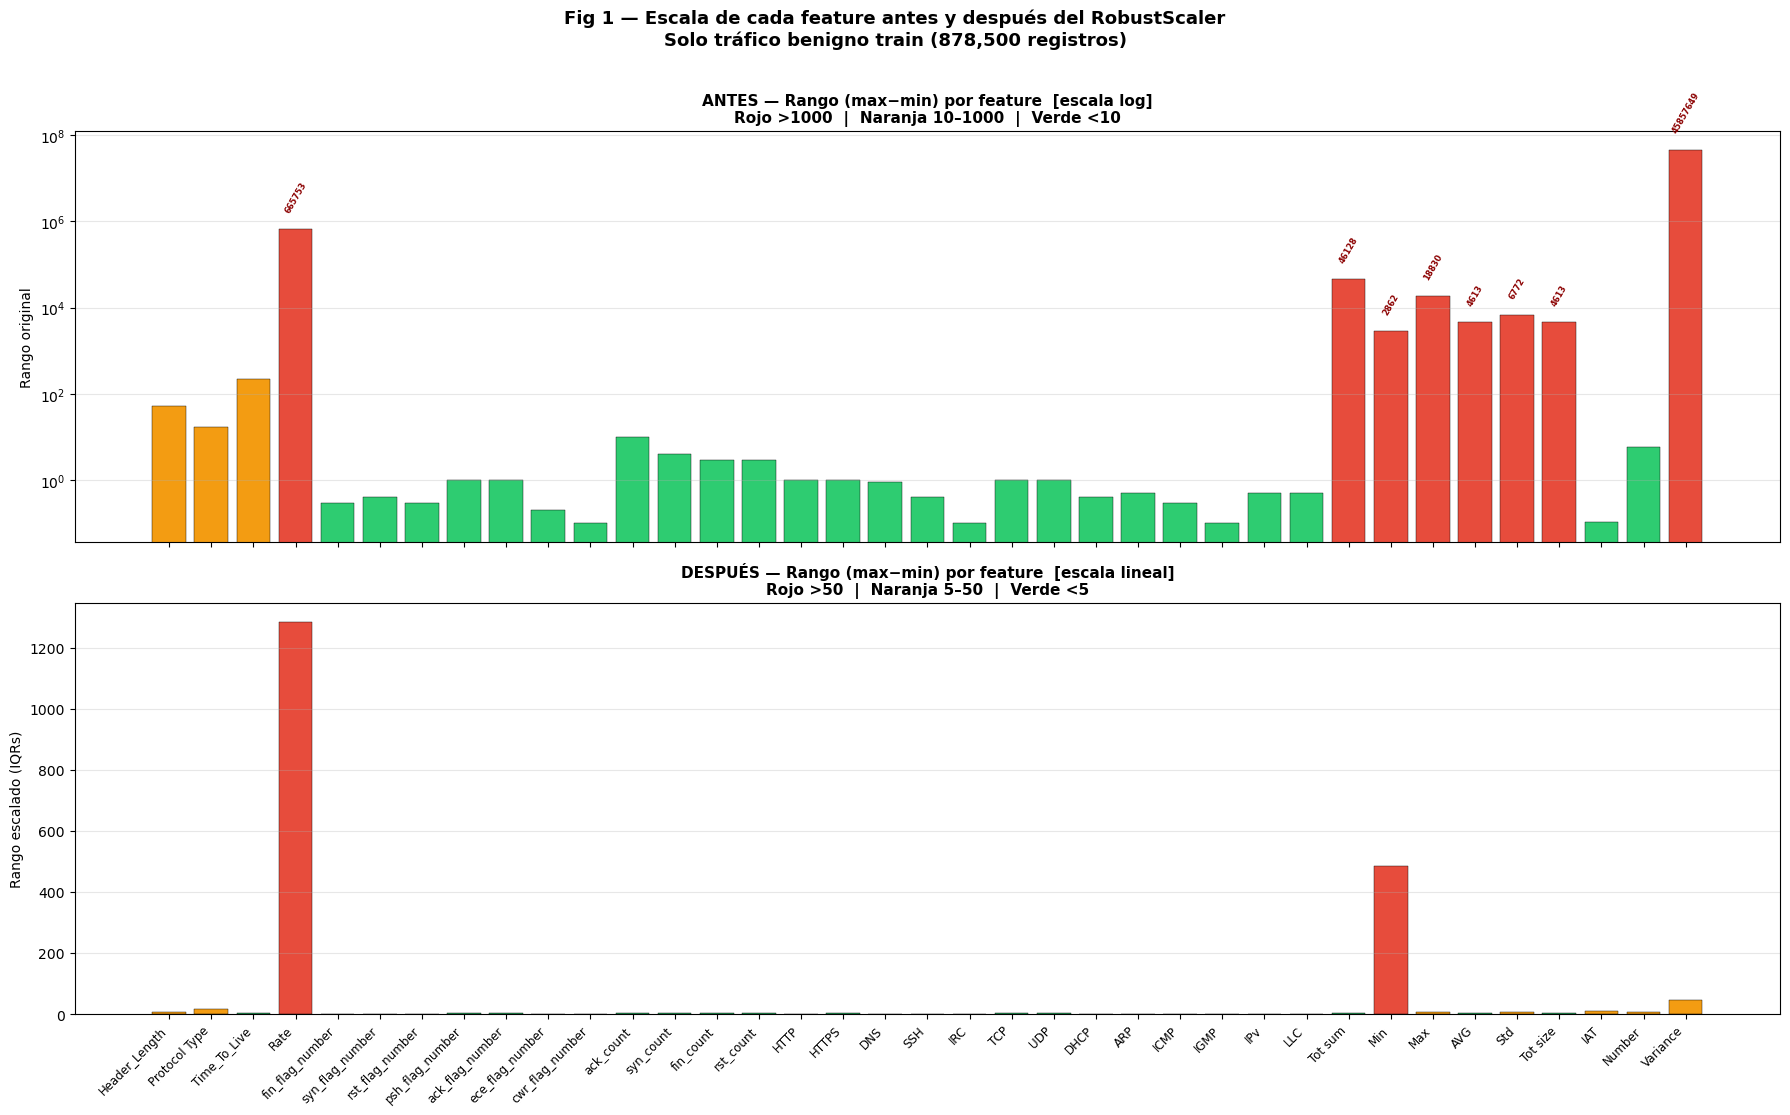

✓ fig1_rangos.png



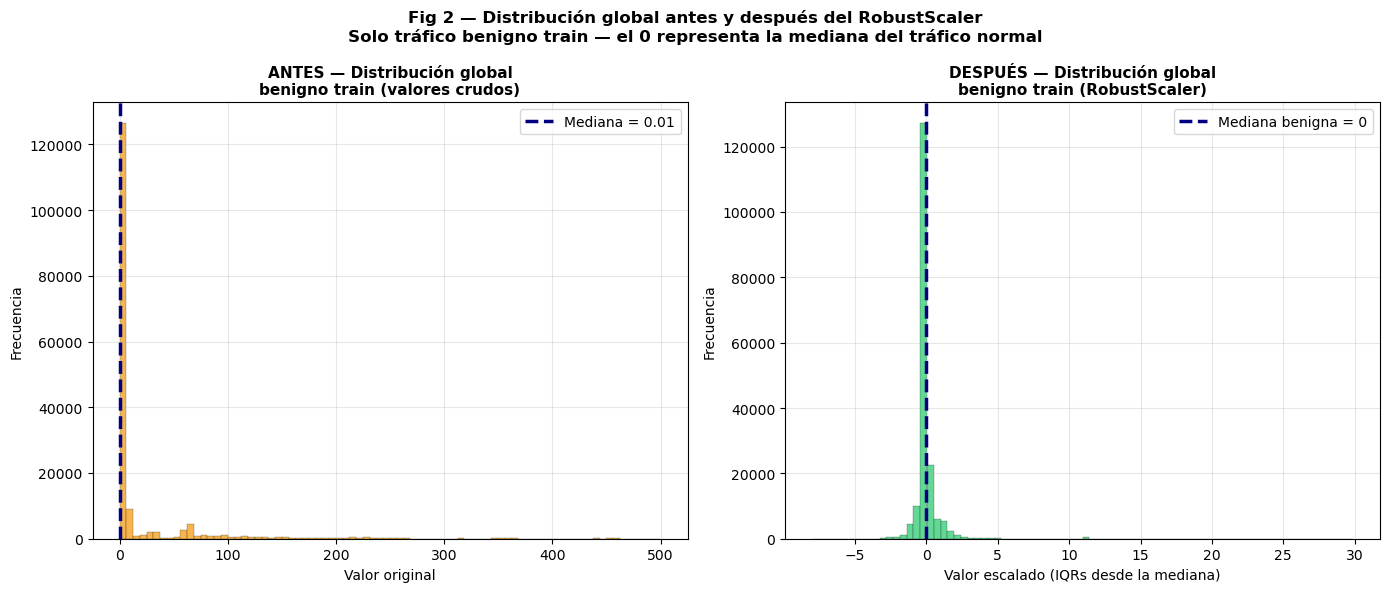

✓ fig2_distribucion_global.png



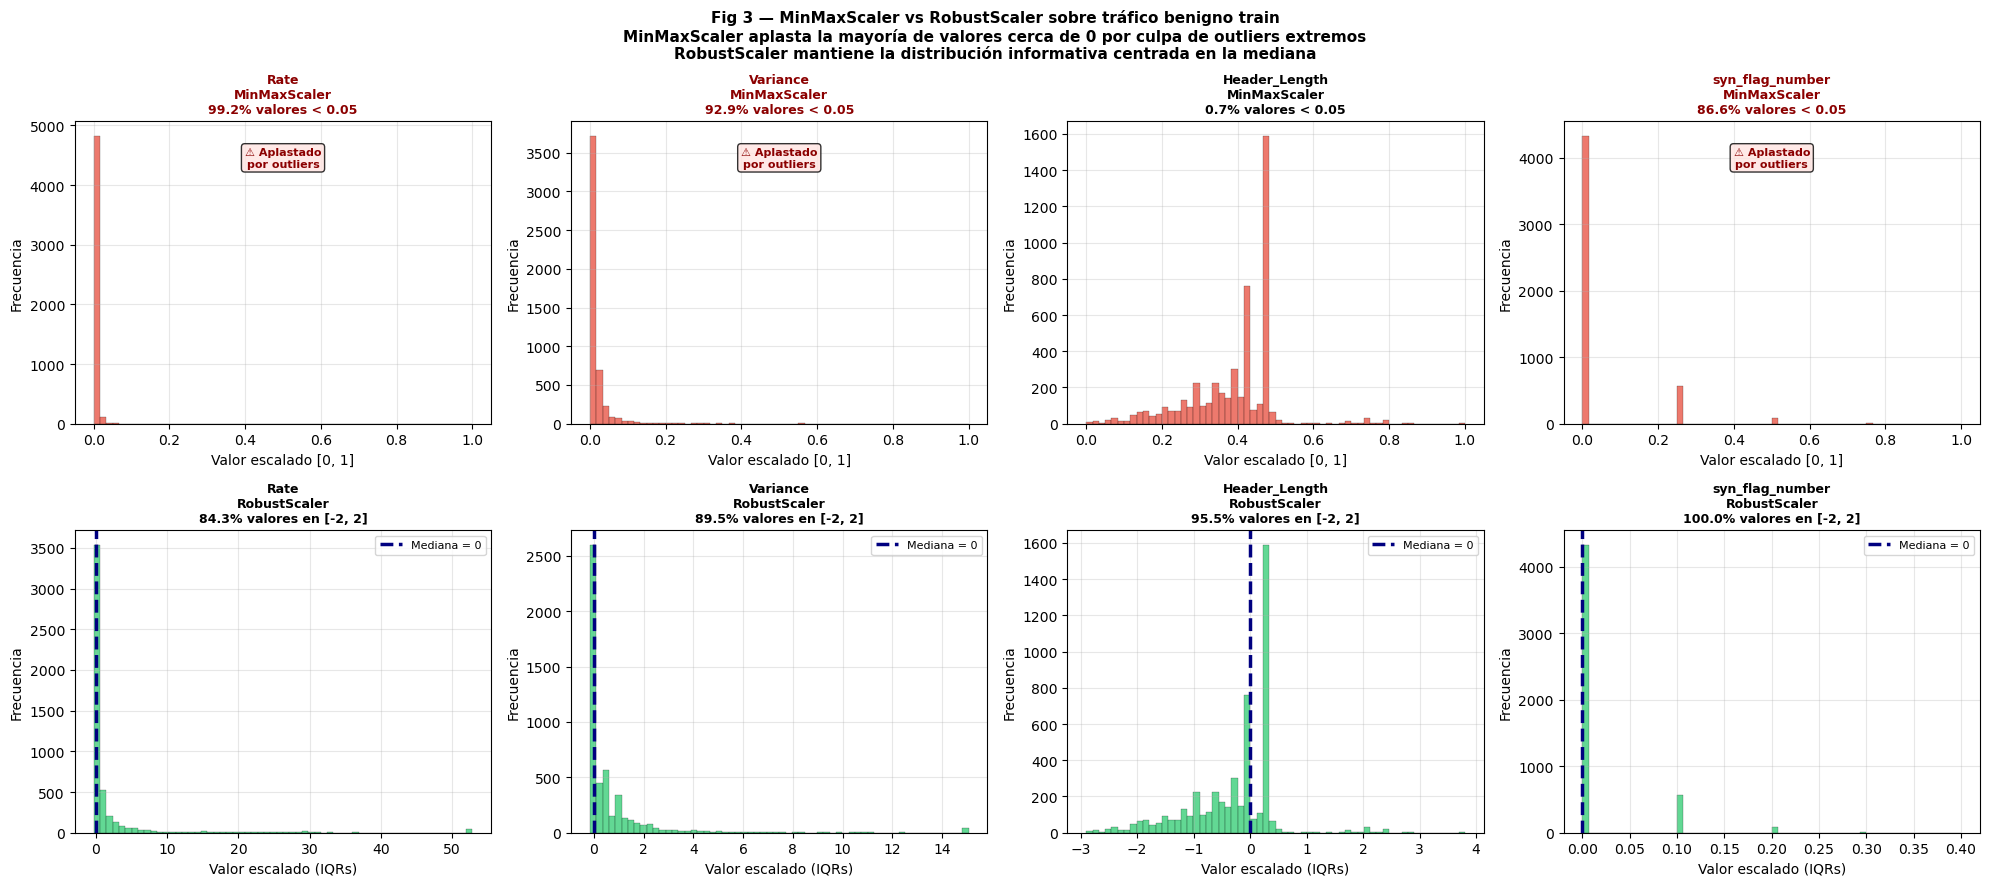

✓ fig3_minmax_vs_robust.png



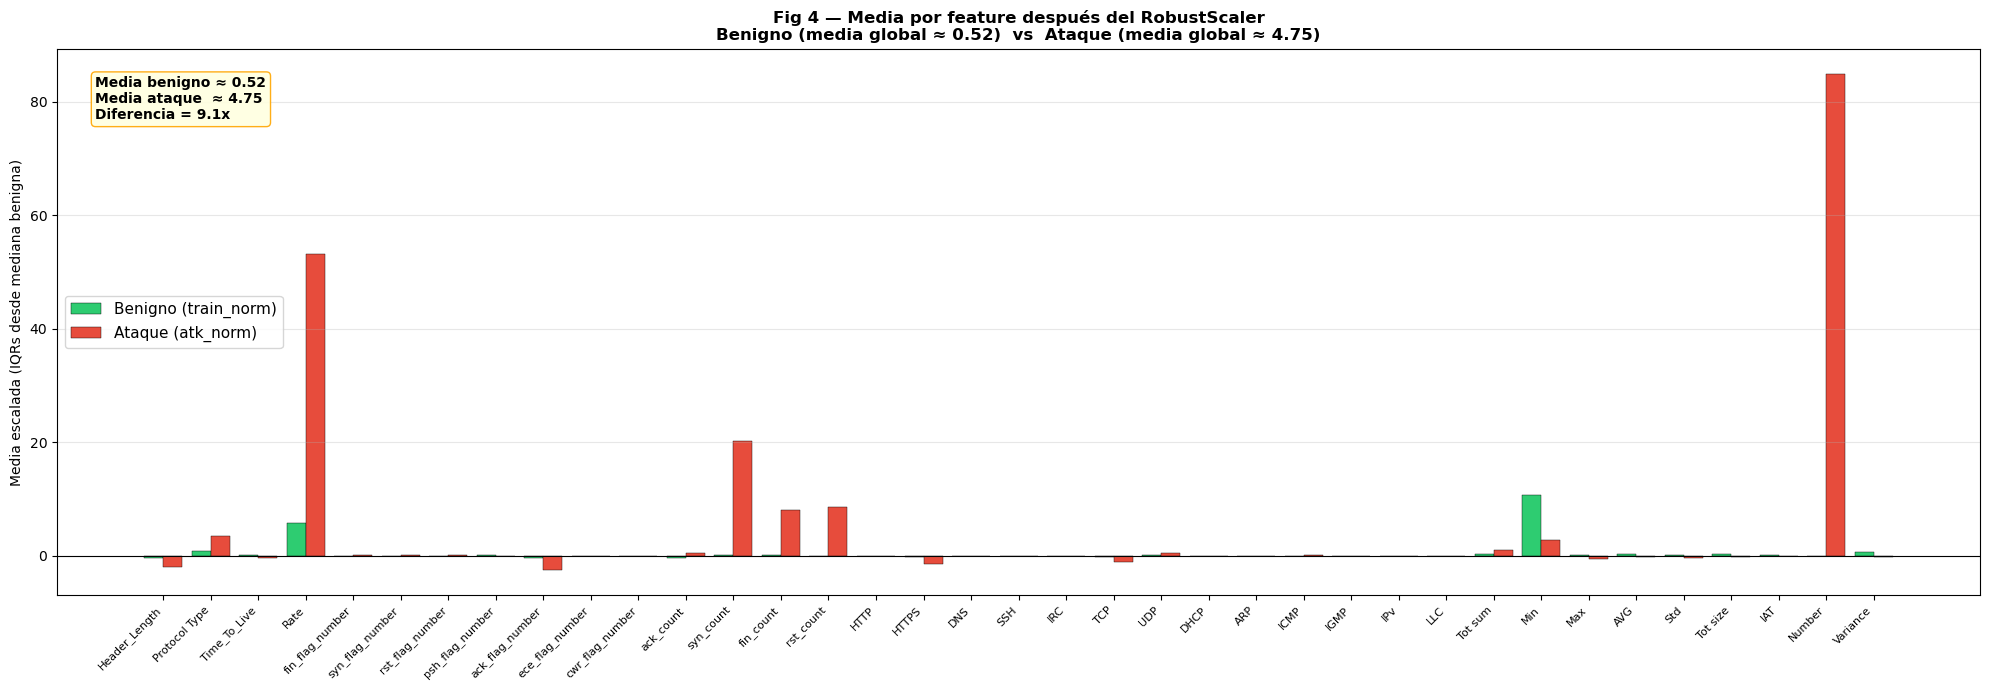

✓ fig4_separabilidad.png



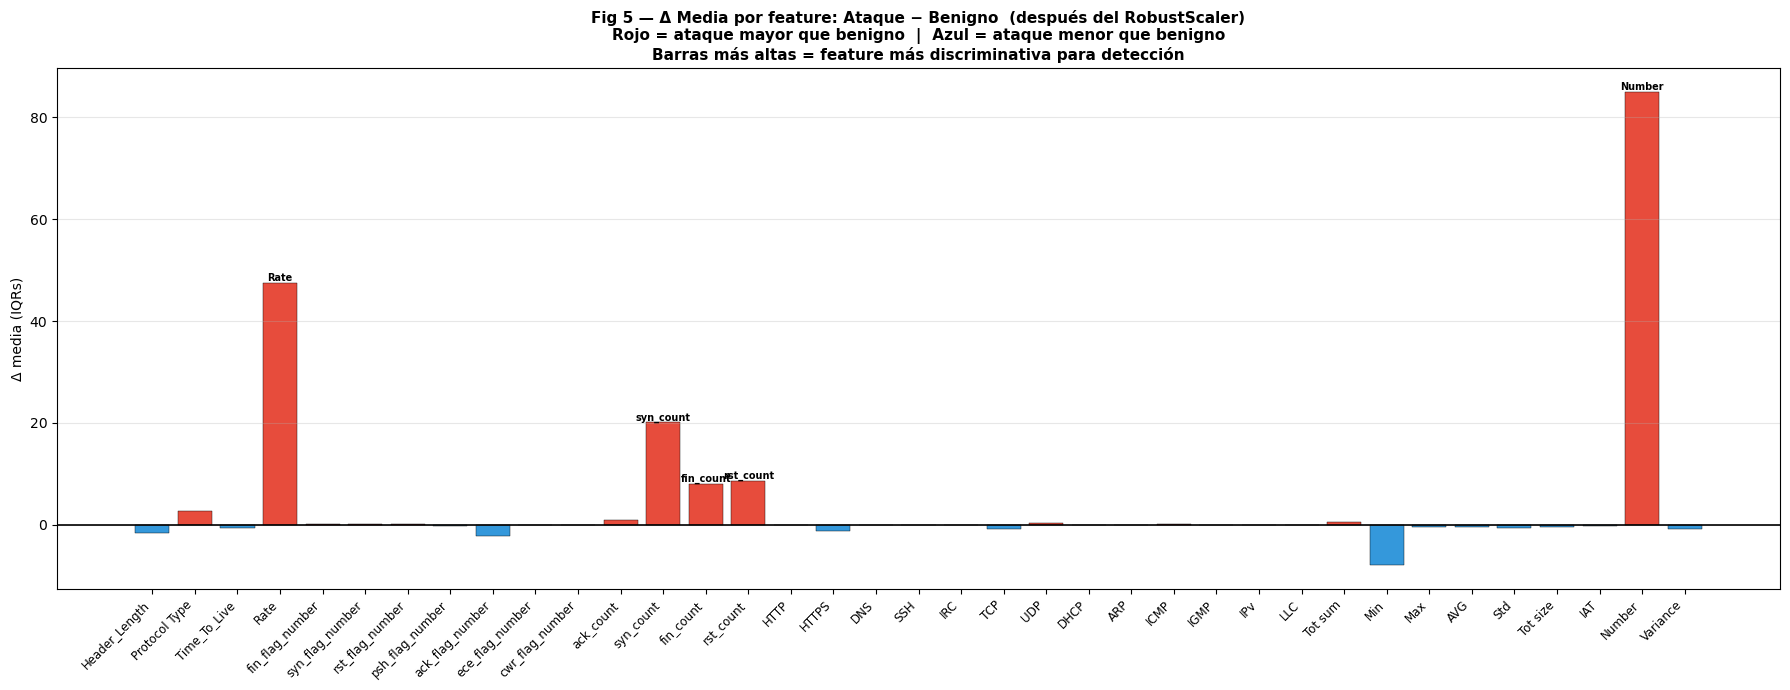

✓ fig5_delta_medias.png

  5 figuras guardadas en graficas_comparativa/
  fig1_rangos.png          → defiende reducción de escala
  fig2_distribucion.png    → defiende centrado en 0
  fig3_minmax_vs_robust.png → defiende elección del scaler
  fig4_separabilidad.png   → defiende que los datos son separables
  fig5_delta_medias.png    → identifica features discriminativas


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════
# CONFIGURACIÓN
# ════════════════════════════════════════════════════════════════
BASE     = Path(r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz")
PART_DIR = BASE / "particiones"
NORM_DIR = BASE / "normalizacion"
GRAF_DIR = BASE / "graficas_comparativa"
GRAF_DIR.mkdir(exist_ok=True)

FEATURES = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'SSH', 'IRC',
    'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

N = 5000
np.random.seed(42)

# ════════════════════════════════════════════════════════════════
# CARGAR DATOS
# Solo benign_train_80.csv → es lo que el scaler vio
# train_norm.npy           → es el resultado del scaler sobre ese mismo set
# atk_norm.npy             → solo para Fig 4 y Fig 5 (separabilidad)
# ════════════════════════════════════════════════════════════════
print("Cargando benign_train_80.csv (ANTES)...")
ben_raw = (pd.read_csv(PART_DIR / "benign_train_80.csv",
                       usecols=FEATURES, nrows=50000)
             .sample(N, random_state=42).reset_index(drop=True))

print("Cargando train_norm.npy (DESPUÉS)...")
arr = np.load(NORM_DIR / "train_norm.npy")
ben_norm = pd.DataFrame(
    arr[np.random.choice(len(arr), N, replace=False)], columns=FEATURES)
del arr

print("Cargando atk_norm.npy (solo para separabilidad)...")
arr = np.load(NORM_DIR / "atk_norm.npy")
atk_norm = pd.DataFrame(
    arr[np.random.choice(len(arr), N, replace=False)], columns=FEATURES)
del arr

print("Datos listos.\n")

# ════════════════════════════════════════════════════════════════
# FIGURA 1 — RANGO (max-min) POR FEATURE
# Solo benigno train — demuestra que el scaler redujo las escalas
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(18, 11), sharex=True)

rangos_a = (ben_raw.max()  - ben_raw.min()).clip(lower=0.01)
rangos_d = (ben_norm.max() - ben_norm.min()).clip(lower=0.01)

col_a = ['#e74c3c' if v > 1000 else '#f39c12' if v > 10 else '#2ecc71'
         for v in rangos_a]
col_d = ['#e74c3c' if v > 50 else '#f39c12' if v > 5 else '#2ecc71'
         for v in rangos_d]

axes[0].bar(range(len(FEATURES)), rangos_a.values, color=col_a,
            edgecolor='black', linewidth=0.3)
axes[0].set_yscale('log')
axes[0].set_title('ANTES — Rango (max−min) por feature  [escala log]\n'
                  'Rojo >1000  |  Naranja 10–1000  |  Verde <10',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Rango original', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(rangos_a.values):
    if v > 500:
        axes[0].text(i, v * 2.5, f'{v:.0f}', ha='center',
                     fontsize=6, rotation=60,
                     color='darkred', fontweight='bold')

axes[1].bar(range(len(FEATURES)), rangos_d.values, color=col_d,
            edgecolor='black', linewidth=0.3)
axes[1].set_xticks(range(len(FEATURES)))
axes[1].set_xticklabels(FEATURES, rotation=45, ha='right', fontsize=8.5)
axes[1].set_title('DESPUÉS — Rango (max−min) por feature  [escala lineal]\n'
                  'Rojo >50  |  Naranja 5–50  |  Verde <5',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Rango escalado (IQRs)', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Fig 1 — Escala de cada feature antes y después del RobustScaler\n'
             'Solo tráfico benigno train (878,500 registros)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(GRAF_DIR / 'fig1_rangos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig1_rangos.png\n")

# ════════════════════════════════════════════════════════════════
# FIGURA 2 — DISTRIBUCIÓN GLOBAL SOLO BENIGNO TRAIN
# Demuestra que después los valores quedan centrados en 0
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ANTES
v_a = ben_raw.values.flatten()
v_a = v_a[np.isfinite(v_a)]
v_a = v_a[(v_a >= -5) & (v_a <= 500)]
mediana_a = np.median(v_a)
axes[0].hist(v_a, bins=80, color='#f39c12', alpha=0.75,
             edgecolor='black', linewidth=0.2)
axes[0].axvline(mediana_a, color='navy', linewidth=2.5,
                linestyle='--', label=f'Mediana = {mediana_a:.2f}')
axes[0].set_title('ANTES — Distribución global\nbenigno train (valores crudos)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Valor original')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# DESPUÉS
v_d = ben_norm.values.flatten()
v_d = v_d[np.isfinite(v_d)]
v_d = v_d[(v_d >= -10) & (v_d <= 30)]
mediana_d = np.median(v_d)
axes[1].hist(v_d, bins=80, color='#2ecc71', alpha=0.75,
             edgecolor='black', linewidth=0.2)
axes[1].axvline(0, color='navy', linewidth=2.5,
                linestyle='--', label='Mediana benigna = 0')
axes[1].set_title('DESPUÉS — Distribución global\nbenigno train (RobustScaler)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Valor escalado (IQRs desde la mediana)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('Fig 2 — Distribución global antes y después del RobustScaler\n'
             'Solo tráfico benigno train — el 0 representa la mediana del tráfico normal',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(GRAF_DIR / 'fig2_distribucion_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig2_distribucion_global.png\n")

# ════════════════════════════════════════════════════════════════
# FIGURA 3 — MINMAXSCALER vs ROBUSTSCALER
# La figura más importante para defender la elección del scaler
# ════════════════════════════════════════════════════════════════
FEATS_DEMO = ['Rate', 'Variance', 'Header_Length', 'syn_flag_number']
datos_demo = ben_raw[FEATS_DEMO].fillna(0).values

mm_scaled = MinMaxScaler().fit_transform(datos_demo)
rb_scaled = RobustScaler().fit_transform(datos_demo)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for i, feat in enumerate(FEATS_DEMO):
    # Fila 0 — MinMaxScaler
    ax = axes[0, i]
    ax.hist(mm_scaled[:, i], bins=60, color='#e74c3c',
            alpha=0.75, edgecolor='black', linewidth=0.2)
    pct_aplastado = (mm_scaled[:, i] < 0.05).mean() * 100
    ax.set_title(f'{feat}\nMinMaxScaler\n{pct_aplastado:.1f}% valores < 0.05',
                 fontweight='bold', fontsize=9,
                 color='darkred' if pct_aplastado > 50 else 'black')
    ax.set_xlabel('Valor escalado [0, 1]')
    ax.set_ylabel('Frecuencia')
    ax.grid(alpha=0.3)
    # Anotación de advertencia si está muy aplastado
    if pct_aplastado > 70:
        ax.text(0.5, 0.85, '⚠ Aplastado\npor outliers',
                transform=ax.transAxes, ha='center',
                color='darkred', fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.8))

    # Fila 1 — RobustScaler
    ax = axes[1, i]
    vals = rb_scaled[:, i]
    p1, p99 = np.percentile(vals, 1), np.percentile(vals, 99)
    vals_clip = np.clip(vals, p1 - 2, p99 + 2)
    ax.hist(vals_clip, bins=60, color='#2ecc71',
            alpha=0.75, edgecolor='black', linewidth=0.2)
    ax.axvline(0, color='navy', linewidth=2.5,
               linestyle='--', label='Mediana = 0')
    pct_centro = ((vals >= -2) & (vals <= 2)).mean() * 100
    ax.set_title(f'{feat}\nRobustScaler\n{pct_centro:.1f}% valores en [-2, 2]',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Valor escalado (IQRs)')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Fig 3 — MinMaxScaler vs RobustScaler sobre tráfico benigno train\n'
             'MinMaxScaler aplasta la mayoría de valores cerca de 0 por culpa de outliers extremos\n'
             'RobustScaler mantiene la distribución informativa centrada en la mediana',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(GRAF_DIR / 'fig3_minmax_vs_robust.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig3_minmax_vs_robust.png\n")

# ════════════════════════════════════════════════════════════════
# FIGURA 4 — SEPARABILIDAD DESPUÉS DEL SCALER
# Demuestra que benigno y ataque son distinguibles tras normalizar
# ════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(20, 7))

x, w = np.arange(len(FEATURES)), 0.4
mb = ben_norm[FEATURES].mean().values
ma = atk_norm[FEATURES].mean().values

ax.bar(x - w/2, mb, w, label='Benigno (train_norm)',
       color='#2ecc71', edgecolor='black', linewidth=0.3)
ax.bar(x + w/2, ma, w, label='Ataque (atk_norm)',
       color='#e74c3c', edgecolor='black', linewidth=0.3)
ax.set_xticks(x)
ax.set_xticklabels(FEATURES, rotation=45, ha='right', fontsize=8)
ax.set_title('Fig 4 — Media por feature después del RobustScaler\n'
             'Benigno (media global ≈ 0.52)  vs  Ataque (media global ≈ 4.75)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Media escalada (IQRs desde mediana benigna)', fontsize=10)
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Anotar la diferencia global
ax.text(0.02, 0.95,
        'Media benigno ≈ 0.52\nMedia ataque  ≈ 4.75\nDiferencia = 9.1x',
        transform=ax.transAxes, fontsize=10, fontweight='bold',
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow',
                  edgecolor='orange', alpha=0.9))

plt.tight_layout()
plt.savefig(GRAF_DIR / 'fig4_separabilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig4_separabilidad.png\n")

# ════════════════════════════════════════════════════════════════
# FIGURA 5 — DELTA DE MEDIAS (ATAQUE − BENIGNO)
# Muestra cuáles features son más discriminativas
# ════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(18, 7))

diff = (atk_norm[FEATURES].mean() - ben_norm[FEATURES].mean()).values
colores = ['#e74c3c' if v > 0 else '#3498db' for v in diff]

bars = ax.bar(range(len(FEATURES)), diff, color=colores,
              edgecolor='black', linewidth=0.3)
ax.axhline(0, color='black', linewidth=1.2)
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha='right', fontsize=8.5)
ax.set_title('Fig 5 — Δ Media por feature: Ataque − Benigno  (después del RobustScaler)\n'
             'Rojo = ataque mayor que benigno  |  Azul = ataque menor que benigno\n'
             'Barras más altas = feature más discriminativa para detección',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Δ media (IQRs)', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Top 5 features más discriminativas
top5_idx = np.argsort(np.abs(diff))[-5:]
for idx in top5_idx:
    ax.text(idx, diff[idx] + (0.3 if diff[idx] > 0 else -0.5),
            FEATURES[idx], ha='center', fontsize=7,
            fontweight='bold', color='black')

plt.tight_layout()
plt.savefig(GRAF_DIR / 'fig5_delta_medias.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig5_delta_medias.png\n")

print("=" * 55)
print("  5 figuras guardadas en graficas_comparativa/")
print("=" * 55)
print("  fig1_rangos.png          → defiende reducción de escala")
print("  fig2_distribucion.png    → defiende centrado en 0")
print("  fig3_minmax_vs_robust.png → defiende elección del scaler")
print("  fig4_separabilidad.png   → defiende que los datos son separables")
print("  fig5_delta_medias.png    → identifica features discriminativas")

Cargando benign_train_80.csv (ANTES)...
Cargando train_norm.npy (DESPUÉS)...
Listo.



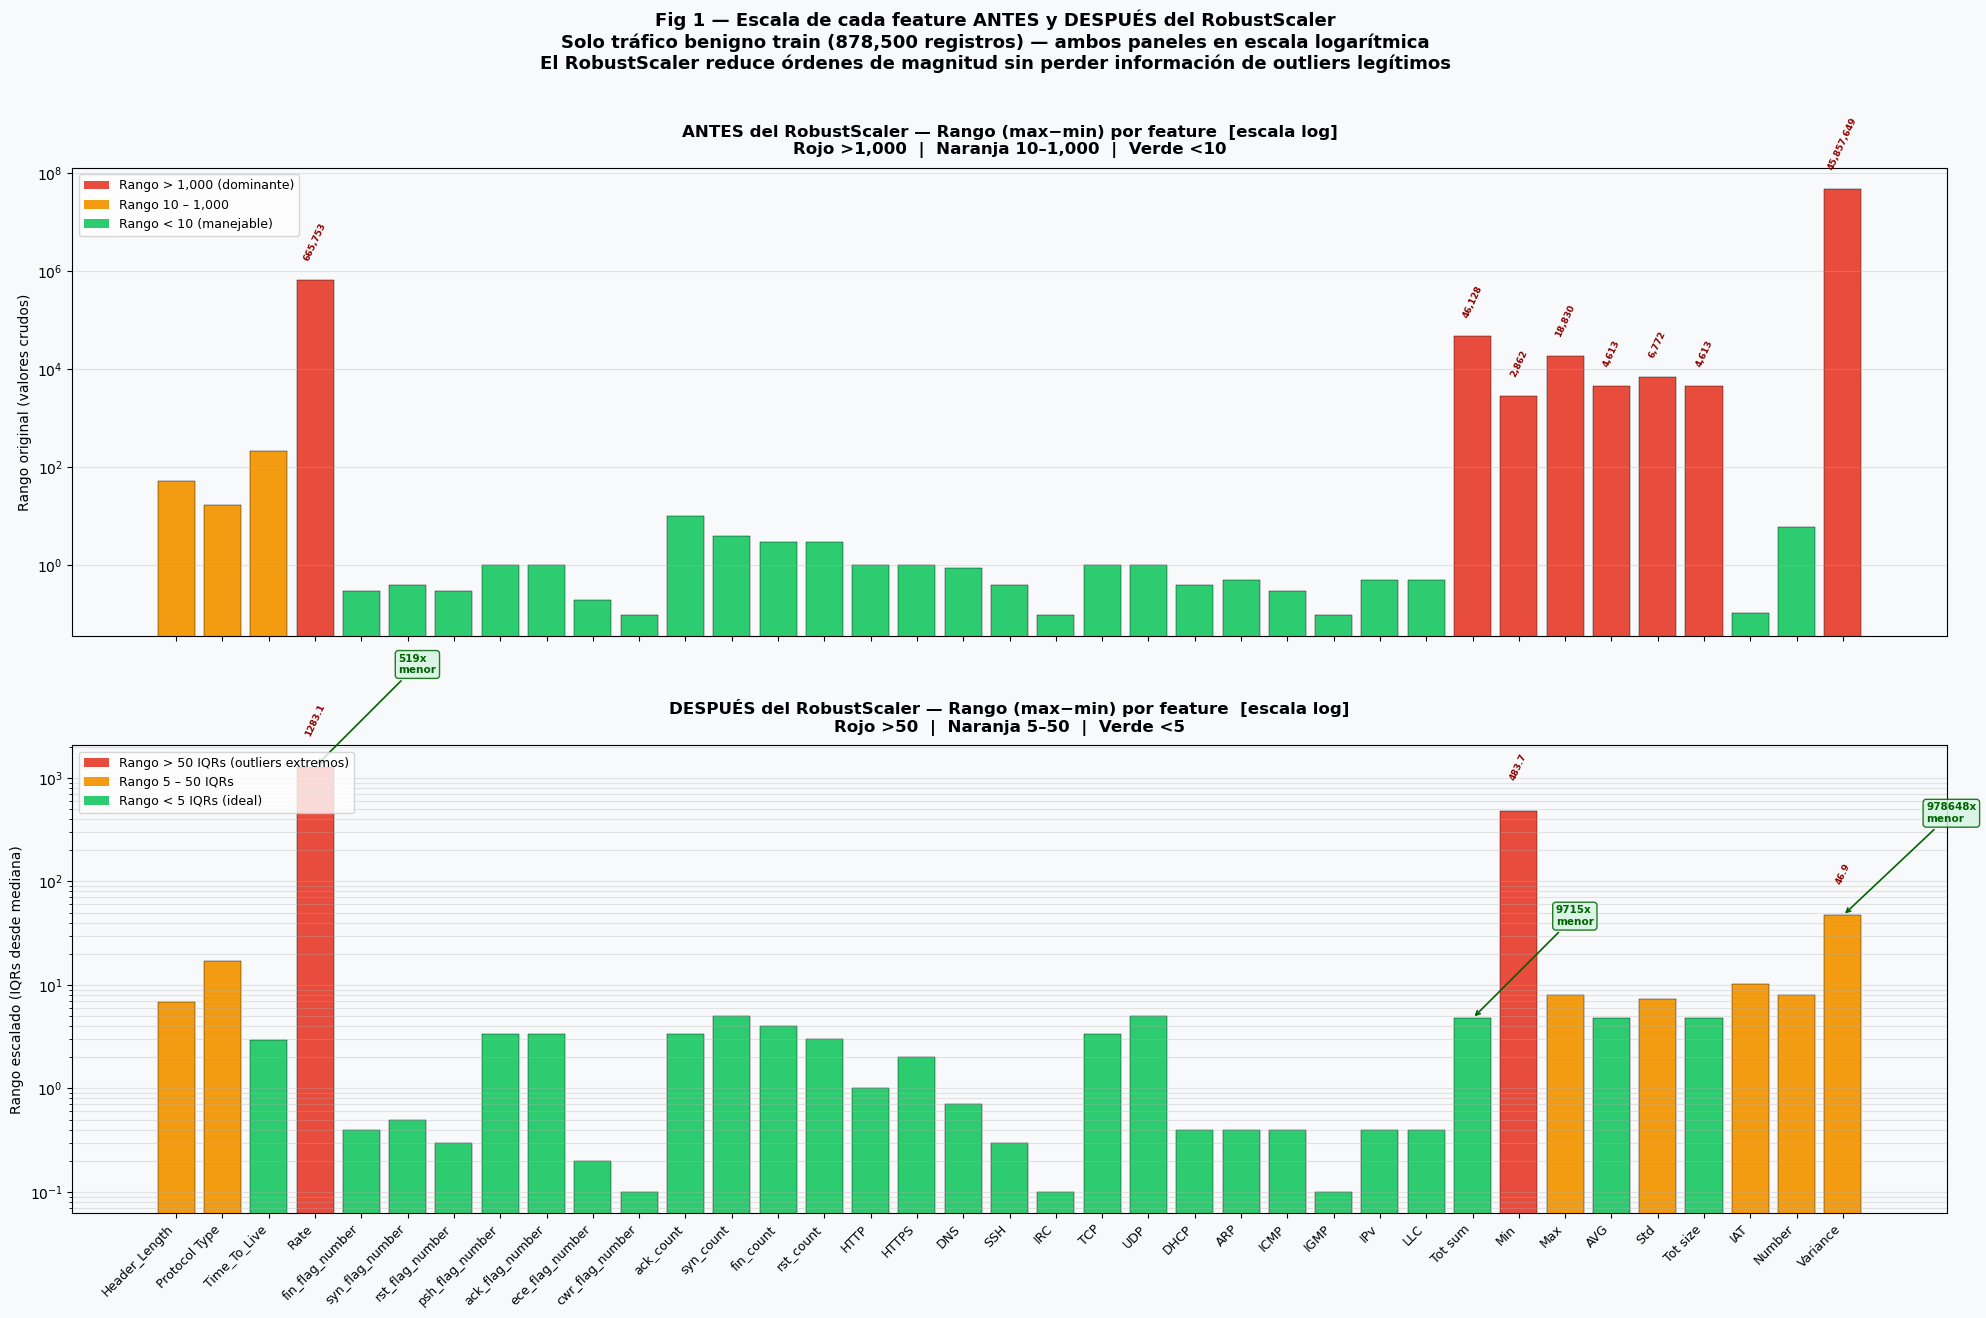


  REDUCCIÓN DE RANGO POR FEATURE (top 10)
  Feature                        Antes      Después    Reducción
  --------------------------------------------------------------
  Variance                45,857,648.8      46.8582     978,648x
  Tot sum                     46,128.0       4.7483       9,715x
  Max                         18,830.0       7.9502       2,368x
  Tot size                     4,612.8       4.7483         971x
  AVG                          4,612.8       4.7483         971x
  Std                          6,771.8       7.2879         929x
  Rate                       665,752.8   1,283.0708         519x
  Time_To_Live                   216.4       2.9267          74x
  Header_Length                   53.6       6.8000           8x
  Min                          2,862.0     483.6667           6x

✓ fig1_rangos_log.png guardada


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE     = Path(r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz")
PART_DIR = BASE / "particiones"
NORM_DIR = BASE / "normalizacion"
GRAF_DIR = BASE / "graficas_comparativa"
GRAF_DIR.mkdir(exist_ok=True)

FEATURES = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'SSH', 'IRC',
    'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

N = 5000
np.random.seed(42)

# ── Cargar datos ─────────────────────────────────────────────
print("Cargando benign_train_80.csv (ANTES)...")
ben_raw = (pd.read_csv(PART_DIR / "benign_train_80.csv",
                       usecols=FEATURES, nrows=50000)
             .sample(N, random_state=42).reset_index(drop=True))

print("Cargando train_norm.npy (DESPUÉS)...")
arr = np.load(NORM_DIR / "train_norm.npy")
ben_norm = pd.DataFrame(
    arr[np.random.choice(len(arr), N, replace=False)], columns=FEATURES)
del arr
print("Listo.\n")

# ── Calcular rangos ──────────────────────────────────────────
rangos_a = (ben_raw.max()  - ben_raw.min()).clip(lower=1e-4)
rangos_d = (ben_norm.max() - ben_norm.min()).clip(lower=1e-4)

# ── Colores ANTES: rojo >1000, naranja 10-1000, verde <10 ────
col_a = ['#e74c3c' if v > 1000 else '#f39c12' if v > 10 else '#2ecc71'
         for v in rangos_a]

# ── Colores DESPUÉS: misma lógica para comparar visualmente ──
col_d = ['#e74c3c' if v > 50 else '#f39c12' if v > 5 else '#2ecc71'
         for v in rangos_d]

# ════════════════════════════════════════════════════════════
# FIGURA — dos paneles, AMBOS en escala logarítmica
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(20, 13), sharex=True)
fig.patch.set_facecolor('#f8f9fa')

# ── PANEL SUPERIOR — ANTES ──────────────────────────────────
ax = axes[0]
ax.set_facecolor('#f8f9fa')
ax.bar(range(len(FEATURES)), rangos_a.values, color=col_a,
       edgecolor='black', linewidth=0.3)
ax.set_yscale('log')
ax.set_title('ANTES del RobustScaler — Rango (max−min) por feature  [escala log]\n'
             'Rojo >1,000  |  Naranja 10–1,000  |  Verde <10',
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Rango original (valores crudos)', fontsize=10)
ax.grid(axis='y', alpha=0.3, which='both')

# Anotar los valores más extremos
for i, v in enumerate(rangos_a.values):
    if v > 1000:
        ax.text(i, v * 2.5, f'{v:,.0f}', ha='center',
                fontsize=6.5, rotation=65,
                color='darkred', fontweight='bold')

# ── PANEL INFERIOR — DESPUÉS ─────────────────────────────────
ax = axes[1]
ax.set_facecolor('#f8f9fa')
ax.bar(range(len(FEATURES)), rangos_d.values, color=col_d,
       edgecolor='black', linewidth=0.3)
ax.set_yscale('log')   # ← LOGARÍTMICA también
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha='right', fontsize=9)
ax.set_title('DESPUÉS del RobustScaler — Rango (max−min) por feature  [escala log]\n'
             'Rojo >50  |  Naranja 5–50  |  Verde <5',
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Rango escalado (IQRs desde mediana)', fontsize=10)
ax.grid(axis='y', alpha=0.3, which='both')

# Anotar los valores más extremos del después
for i, v in enumerate(rangos_d.values):
    if v > 20:
        ax.text(i, v * 2.0, f'{v:.1f}', ha='center',
                fontsize=6.5, rotation=65,
                color='darkred', fontweight='bold')

# ── Anotaciones de reducción en los casos más notorios ───────
reducciones = {
    'Rate':     (rangos_a['Rate'],     rangos_d['Rate']),
    'Variance': (rangos_a['Variance'], rangos_d['Variance']),
    'Tot sum':  (rangos_a['Tot sum'],  rangos_d['Tot sum']),
}

for feat, (v_antes, v_despues) in reducciones.items():
    i = FEATURES.index(feat)
    reduccion = v_antes / v_despues
    axes[1].annotate(
        f'{reduccion:.0f}x\nmenor',
        xy=(i, v_despues),
        xytext=(i + 1.8, v_despues * 8),
        fontsize=7.5, color='darkgreen', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor='#d5f5e3', edgecolor='darkgreen', alpha=0.85)
    )

# ── Leyenda de colores ────────────────────────────────────────
from matplotlib.patches import Patch
leyenda_antes = [
    Patch(facecolor='#e74c3c', label='Rango > 1,000 (dominante)'),
    Patch(facecolor='#f39c12', label='Rango 10 – 1,000'),
    Patch(facecolor='#2ecc71', label='Rango < 10 (manejable)'),
]
leyenda_despues = [
    Patch(facecolor='#e74c3c', label='Rango > 50 IQRs (outliers extremos)'),
    Patch(facecolor='#f39c12', label='Rango 5 – 50 IQRs'),
    Patch(facecolor='#2ecc71', label='Rango < 5 IQRs (ideal)'),
]
axes[0].legend(handles=leyenda_antes, fontsize=9, loc='upper left')
axes[1].legend(handles=leyenda_despues, fontsize=9, loc='upper left')

plt.suptitle(
    'Fig 1 — Escala de cada feature ANTES y DESPUÉS del RobustScaler\n'
    'Solo tráfico benigno train (878,500 registros) — ambos paneles en escala logarítmica\n'
    'El RobustScaler reduce órdenes de magnitud sin perder información de outliers legítimos',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(GRAF_DIR / 'fig1_rangos_log.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Imprimir tabla de reducción ───────────────────────────────
print("\n  REDUCCIÓN DE RANGO POR FEATURE (top 10)")
print(f"  {'Feature':20} {'Antes':>15} {'Después':>12} {'Reducción':>12}")
print(f"  {'-'*62}")
ratio = (rangos_a / rangos_d).sort_values(ascending=False)
for feat in ratio.index[:10]:
    print(f"  {feat:20} {rangos_a[feat]:>15,.1f} "
          f"{rangos_d[feat]:>12,.4f} "
          f"{ratio[feat]:>11,.0f}x")
print("\n✓ fig1_rangos_log.png guardada")

Cargando benign_train_80.csv...
Cargando train_norm.npy...
Listo.



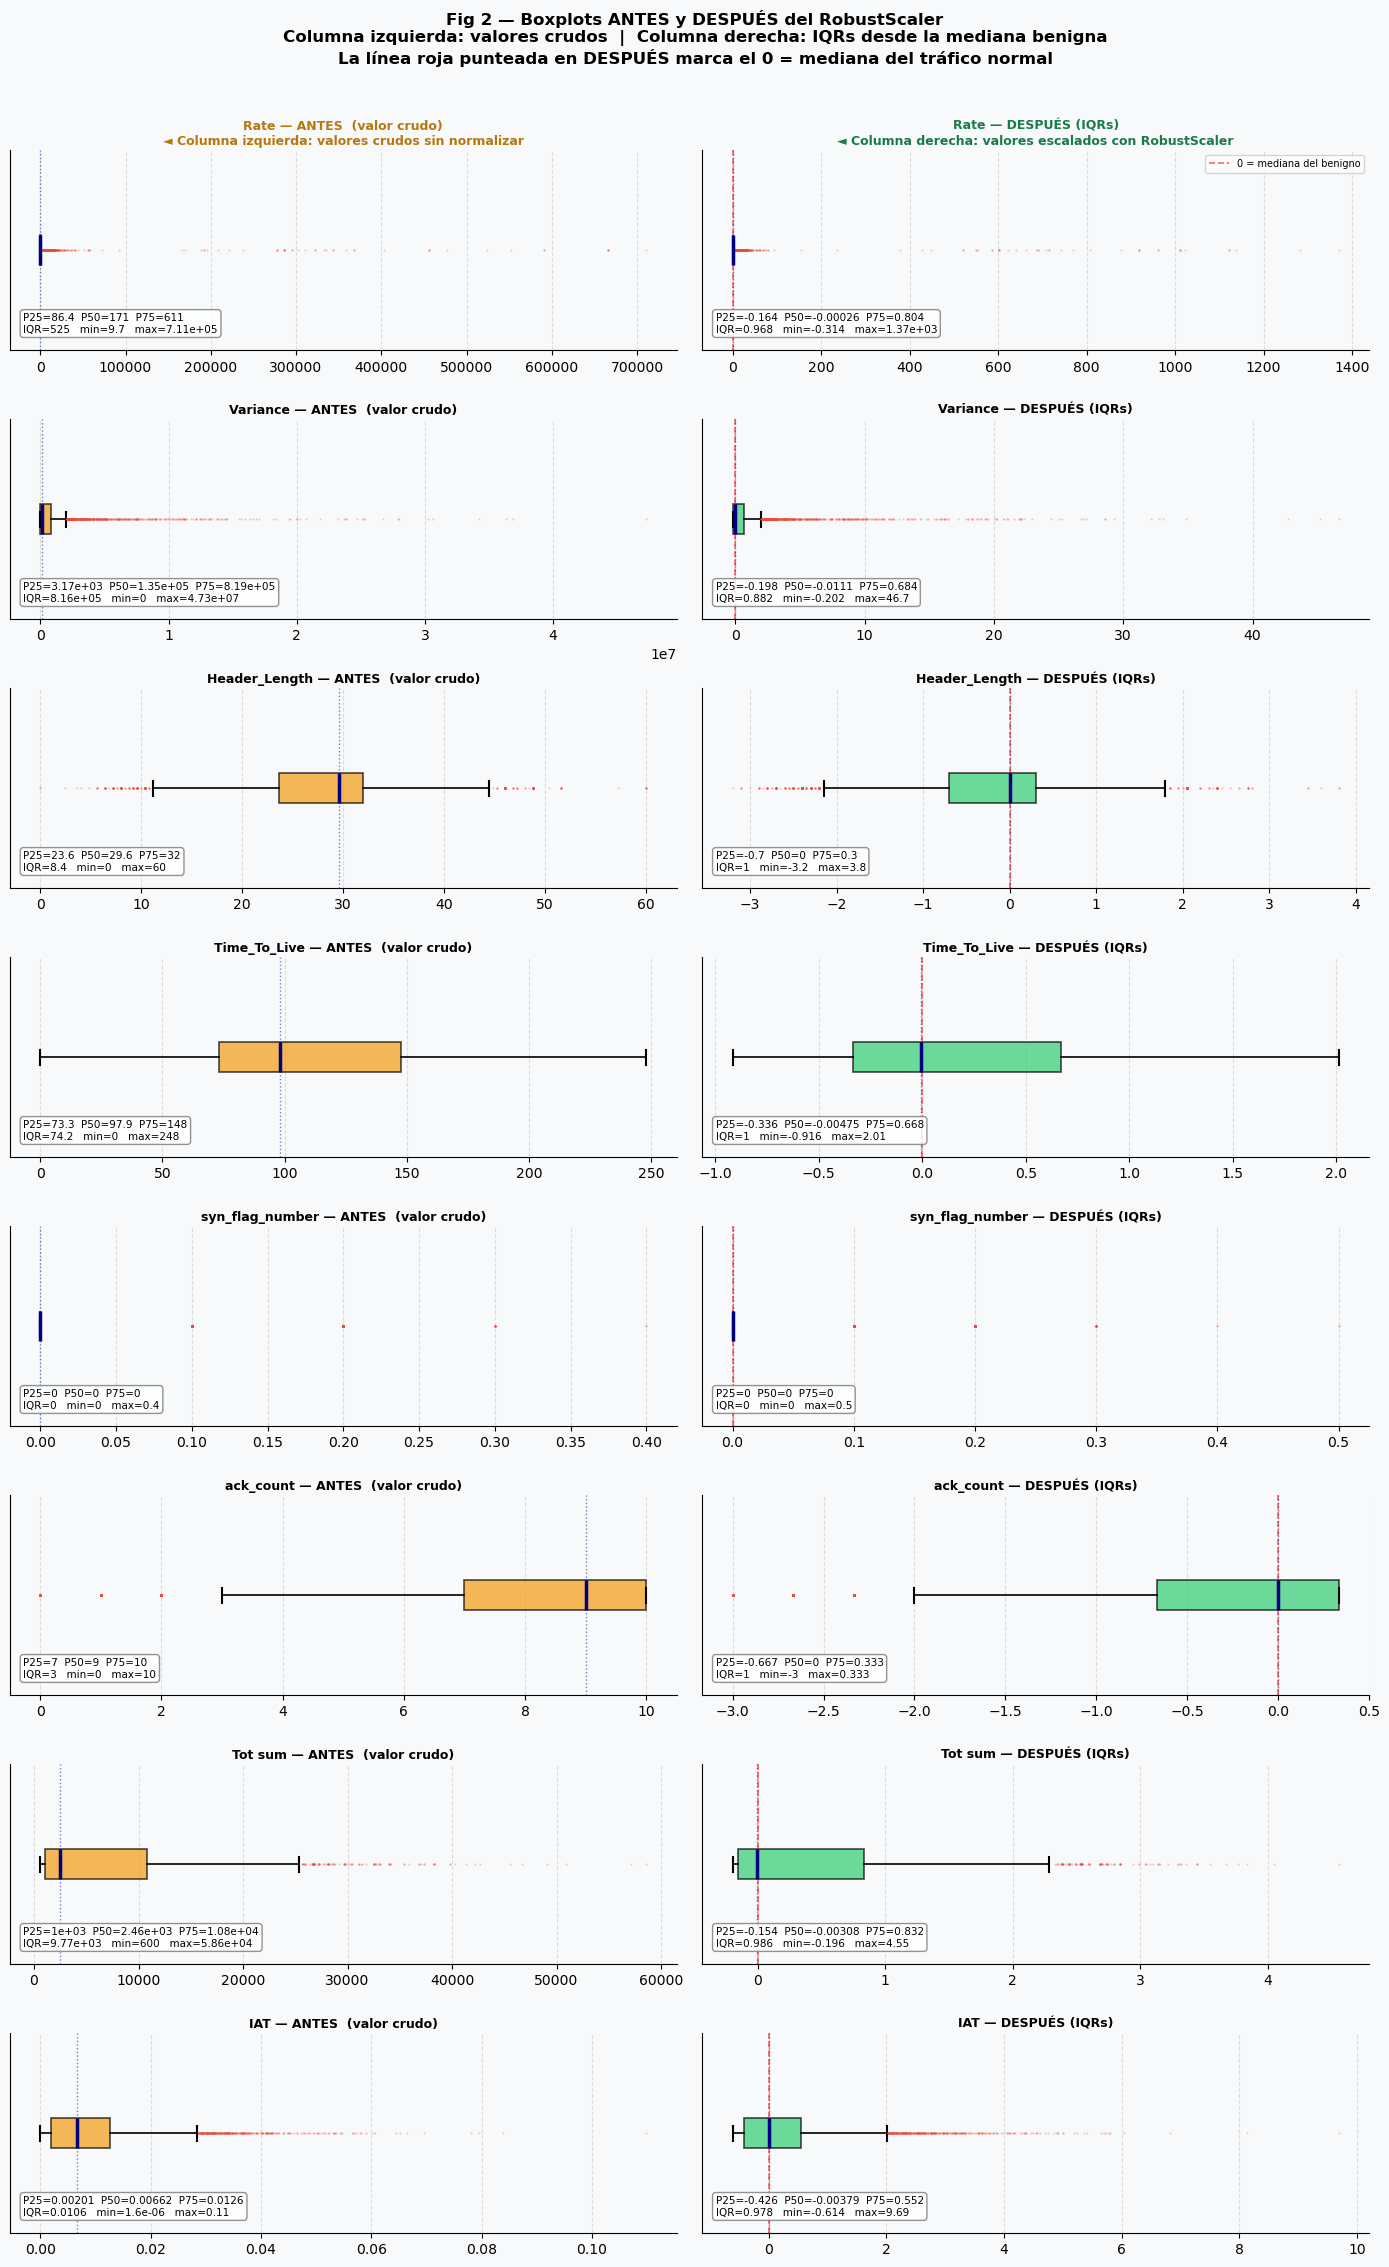

✓ fig2_boxplots_antes_despues.png

  Feature                 IQR Antes   IQR Después    Reducción
  ------------------------------------------------------------
  Rate                       525.01        0.9676         543x
  Variance               815,852.59        0.8818     925,217x
  Header_Length                8.40        1.0000           8x
  Time_To_Live                74.20        1.0041          74x
  syn_flag_number              0.00        0.0000           0x
  ack_count                    3.00        1.0000           3x
  Tot sum                  9,768.50        0.9861       9,906x
  IAT                          0.01        0.9780           0x

✓ Guardado en: C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz\graficas_comparativa


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE     = Path(r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz")
PART_DIR = BASE / "particiones"
NORM_DIR = BASE / "normalizacion"
GRAF_DIR = BASE / "graficas_comparativa"
GRAF_DIR.mkdir(exist_ok=True)

FEATURES = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'SSH', 'IRC',
    'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

# Features clave para los boxplots — elegidas por ser las más representativas
# para argumentar cada caso en la defensa
FEATS_BOXPLOT = [
    'Rate',            # outlier extremo — el caso más dramático
    'Variance',        # el más extremo en reducción (978,648x)
    'Header_Length',   # naranja antes → verde después
    'Time_To_Live',    # naranja antes → verde después
    'syn_flag_number', # flag TCP — pequeño rango, clave para SYN flood
    'ack_count',       # conteo TCP — distribución asimétrica
    'Tot sum',         # suma de bytes — rango grande
    'IAT',             # inter-arrival time — distribución peculiar
]

N = 8000
np.random.seed(42)

# ── Cargar datos ─────────────────────────────────────────────
print("Cargando benign_train_80.csv...")
ben_raw = (pd.read_csv(PART_DIR / "benign_train_80.csv",
                       usecols=FEATURES, nrows=60000)
             .sample(N, random_state=42).reset_index(drop=True))

print("Cargando train_norm.npy...")
arr = np.load(NORM_DIR / "train_norm.npy")
idx = np.random.choice(len(arr), N, replace=False)
ben_norm = pd.DataFrame(arr[idx], columns=FEATURES)
del arr
print("Listo.\n")

# ════════════════════════════════════════════════════════════
# FIGURA — 8 features, 2 columnas (ANTES | DESPUÉS)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(len(FEATS_BOXPLOT), 2,
                         figsize=(14, len(FEATS_BOXPLOT) * 2.8))
fig.patch.set_facecolor('#f8f9fa')

for row, feat in enumerate(FEATS_BOXPLOT):

    datos_a = ben_raw[feat].dropna().values
    datos_d = ben_norm[feat].dropna().values

    for col, (datos, titulo_panel, color_box) in enumerate([
        (datos_a, 'ANTES  (valor crudo)',    '#f39c12'),
        (datos_d, 'DESPUÉS (IQRs)',          '#2ecc71'),
    ]):
        ax = axes[row, col]
        ax.set_facecolor('#f8f9fa')

        # ── Boxplot ──────────────────────────────────────────
        bp = ax.boxplot(datos, vert=False, patch_artist=True,
                        showfliers=True,
                        flierprops=dict(marker='o', markersize=1.5,
                                        alpha=0.3,
                                        markerfacecolor='#e74c3c',
                                        markeredgecolor='none'),
                        medianprops=dict(color='navy', linewidth=2.5),
                        whiskerprops=dict(linewidth=1.2),
                        capprops=dict(linewidth=1.5),
                        boxprops=dict(linewidth=1.2))
        bp['boxes'][0].set_facecolor(color_box)
        bp['boxes'][0].set_alpha(0.7)

        # ── Estadísticas ──────────────────────────────────────
        p25  = np.percentile(datos, 25)
        p50  = np.percentile(datos, 50)
        p75  = np.percentile(datos, 75)
        iqr  = p75 - p25
        mn   = datos.min()
        mx   = datos.max()

        # ── Anotación de estadísticas dentro del panel ────────
        stats_txt = (f'P25={p25:.3g}  P50={p50:.3g}  P75={p75:.3g}\n'
                     f'IQR={iqr:.3g}   min={mn:.3g}   max={mx:.3g}')
        ax.set_title(f'{feat} — {titulo_panel}',
                     fontsize=9, fontweight='bold', pad=4)
        ax.text(0.02, 0.08, stats_txt,
                transform=ax.transAxes, fontsize=7.5,
                verticalalignment='bottom',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='white', alpha=0.85,
                          edgecolor='gray'))

        ax.set_yticks([])
        ax.grid(axis='x', alpha=0.4, linestyle='--')

        # ── Marcar la mediana con línea de referencia ─────────
        ax.axvline(p50, color='navy', linewidth=1,
                   linestyle=':', alpha=0.5)

        # ── En el panel DESPUÉS: marcar 0 como referencia ─────
        if col == 1:
            ax.axvline(0, color='red', linewidth=1.2,
                       linestyle='--', alpha=0.6,
                       label='0 = mediana del benigno')
            if row == 0:
                ax.legend(fontsize=7, loc='upper right')

        # ── Separar paneles visualmente ───────────────────────
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

# ── Encabezados de columna ────────────────────────────────────
axes[0, 0].set_title(
    f'{FEATS_BOXPLOT[0]} — ANTES  (valor crudo)\n'
    '◄ Columna izquierda: valores crudos sin normalizar',
    fontsize=9, fontweight='bold', pad=4, color='#b7770d')
axes[0, 1].set_title(
    f'{FEATS_BOXPLOT[0]} — DESPUÉS (IQRs)\n'
    '◄ Columna derecha: valores escalados con RobustScaler',
    fontsize=9, fontweight='bold', pad=4, color='#1a7a4a')

plt.suptitle(
    'Fig 2 — Boxplots ANTES y DESPUÉS del RobustScaler\n'
    'Columna izquierda: valores crudos  |  Columna derecha: IQRs desde la mediana benigna\n'
    'La línea roja punteada en DESPUÉS marca el 0 = mediana del tráfico normal',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout(h_pad=0.8)
plt.savefig(GRAF_DIR / 'fig2_boxplots_antes_despues.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig2_boxplots_antes_despues.png\n")

# ════════════════════════════════════════════════════════════
# TABLA RESUMEN — IQR antes vs después para argumentar
# ════════════════════════════════════════════════════════════
print("=" * 70)
print(f"  {'Feature':20} {'IQR Antes':>12} {'IQR Después':>13} {'Reducción':>12}")
print(f"  {'-'*60}")
for feat in FEATS_BOXPLOT:
    iqr_a = (np.percentile(ben_raw[feat].dropna(), 75) -
             np.percentile(ben_raw[feat].dropna(), 25))
    iqr_d = (np.percentile(ben_norm[feat].dropna(), 75) -
             np.percentile(ben_norm[feat].dropna(), 25))
    iqr_d = max(iqr_d, 1e-6)
    print(f"  {feat:20} {iqr_a:>12,.2f} {iqr_d:>13,.4f} {iqr_a/iqr_d:>11,.0f}x")
print("=" * 70)
print(f"\n✓ Guardado en: {GRAF_DIR}")

Cargando train_norm.npy ...
Cargando val_norm.npy ...
Listo.



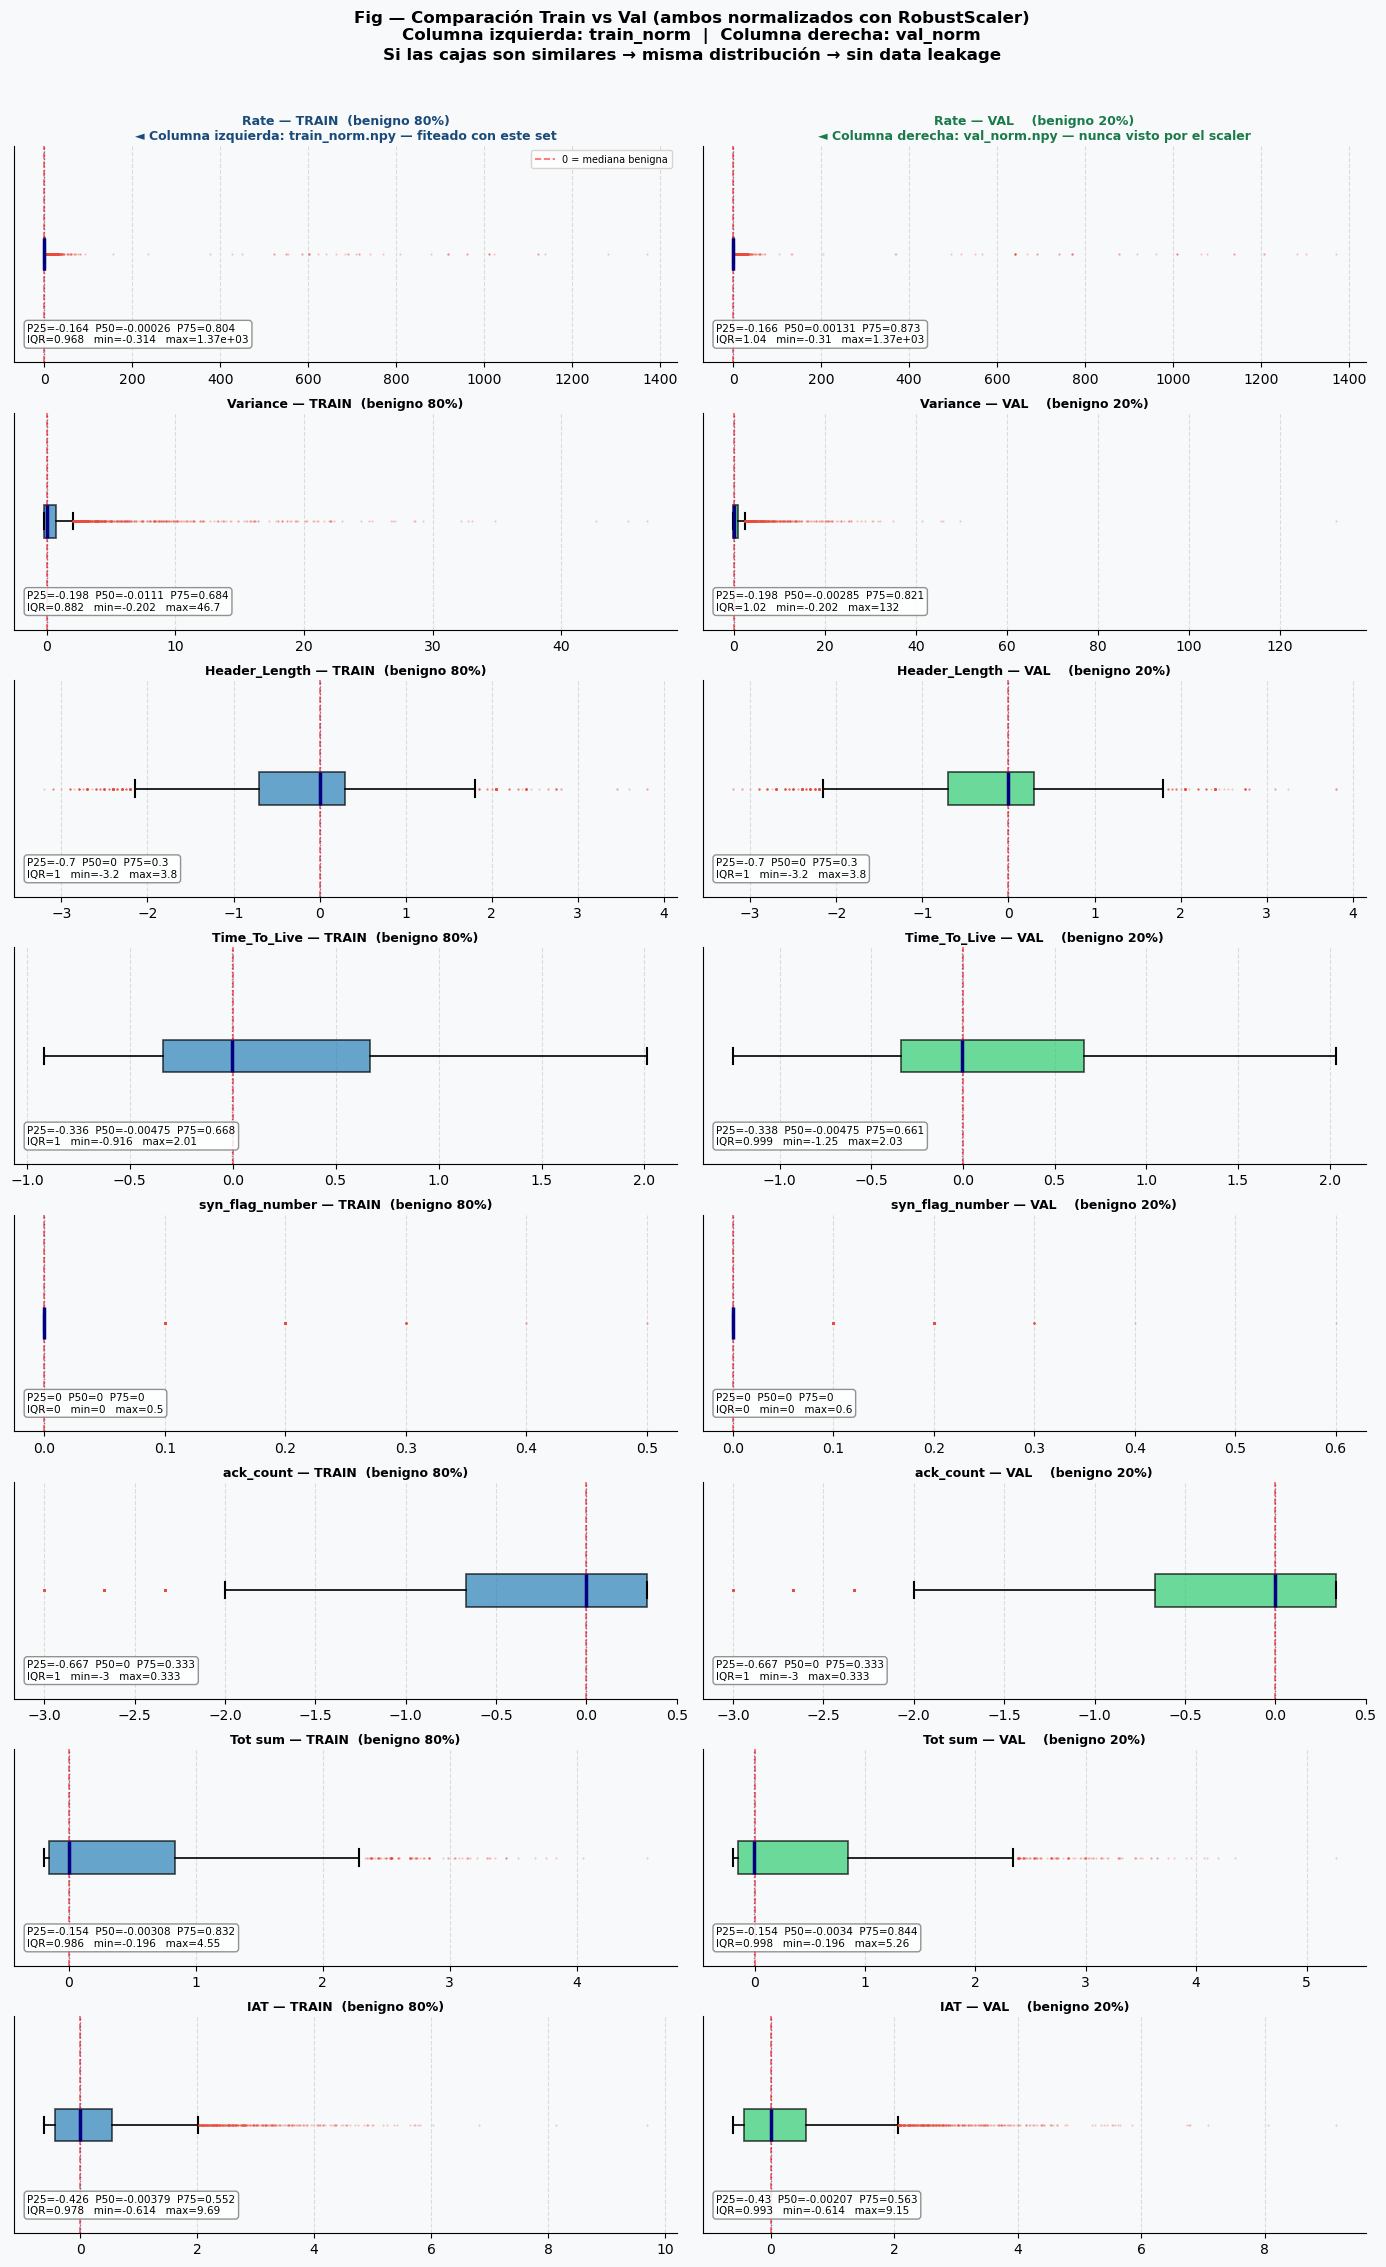

✓ fig_train_vs_val_boxplots.png

  Feature               P50 Train    P50 Val      Δ P50   IQR Train    IQR Val
  -------------------------------------------------------------------------
  ✓ Rate                    -0.0003     0.0013     0.0016      0.9676     1.0394
  ✓ Variance                -0.0111    -0.0029     0.0083      0.8818     1.0191
  ✓ Header_Length            0.0000     0.0000     0.0000      1.0000     1.0000
  ✓ Time_To_Live            -0.0047    -0.0047     0.0000      1.0041     0.9986
  ✓ syn_flag_number          0.0000     0.0000     0.0000      0.0000     0.0000
  ✓ ack_count                0.0000     0.0000     0.0000      1.0000     1.0000
  ✓ Tot sum                 -0.0031    -0.0034     0.0003      0.9861     0.9981
  ✓ IAT                     -0.0038    -0.0021     0.0017      0.9780     0.9932
  -------------------------------------------------------------------------

  Features con Δ P50 < 0.05:  8/8
  Media global train:  0.5147
  Media global val:    

: 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import gc
import warnings
warnings.filterwarnings('ignore')

BASE     = Path(r"C:\Users\Daniel\Desktop\Proyectos\Ia-tesisi\Notebooks_IaTesisz")
NORM_DIR = BASE / "normalizacion"
GRAF_DIR = BASE / "graficas_comparativa"
GRAF_DIR.mkdir(exist_ok=True)

FEATURES = [
    'Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'rst_count', 'HTTP', 'HTTPS', 'DNS', 'SSH', 'IRC',
    'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP',
    'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std',
    'Tot size', 'IAT', 'Number', 'Variance'
]

# Mismas features clave del código anterior
FEATS_BOXPLOT = [
    'Rate',
    'Variance',
    'Header_Length',
    'Time_To_Live',
    'syn_flag_number',
    'ack_count',
    'Tot sum',
    'IAT',
]

N = 8000
np.random.seed(42)

# ════════════════════════════════════════════════════════════
# CARGAR train_norm y val_norm
# Mismo patrón que el código anterior
# ════════════════════════════════════════════════════════════
print("Cargando train_norm.npy ...")
arr = np.load(NORM_DIR / "train_norm.npy")
train = pd.DataFrame(
    arr[np.random.choice(len(arr), N, replace=False)],
    columns=FEATURES)
del arr; gc.collect()

print("Cargando val_norm.npy ...")
arr = np.load(NORM_DIR / "val_norm.npy")
val = pd.DataFrame(
    arr[np.random.choice(len(arr), N, replace=False)],
    columns=FEATURES)
del arr; gc.collect()

print("Listo.\n")

# ════════════════════════════════════════════════════════════
# FIGURA — 8 features, 2 columnas (TRAIN | VAL)
# Misma estructura exacta del código anterior
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(len(FEATS_BOXPLOT), 2,
                         figsize=(14, len(FEATS_BOXPLOT) * 2.8))
fig.patch.set_facecolor('#f8f9fa')

for row, feat in enumerate(FEATS_BOXPLOT):

    datos_t = train[feat].dropna().values
    datos_v = val[feat].dropna().values

    for col, (datos, titulo_panel, color_box) in enumerate([
        (datos_t, 'TRAIN  (benigno 80%)',  '#2980b9'),
        (datos_v, 'VAL    (benigno 20%)',  '#2ecc71'),
    ]):
        ax = axes[row, col]
        ax.set_facecolor('#f8f9fa')

        # ── Boxplot ──────────────────────────────────────────
        bp = ax.boxplot(datos, vert=False, patch_artist=True,
                        showfliers=True,
                        flierprops=dict(marker='o', markersize=1.5,
                                        alpha=0.3,
                                        markerfacecolor='#e74c3c',
                                        markeredgecolor='none'),
                        medianprops=dict(color='navy', linewidth=2.5),
                        whiskerprops=dict(linewidth=1.2),
                        capprops=dict(linewidth=1.5),
                        boxprops=dict(linewidth=1.2))
        bp['boxes'][0].set_facecolor(color_box)
        bp['boxes'][0].set_alpha(0.7)

        # ── Estadísticas ──────────────────────────────────────
        p25 = np.percentile(datos, 25)
        p50 = np.percentile(datos, 50)
        p75 = np.percentile(datos, 75)
        iqr = p75 - p25
        mn  = datos.min()
        mx  = datos.max()

        # ── Anotación de estadísticas ─────────────────────────
        stats_txt = (f'P25={p25:.3g}  P50={p50:.3g}  P75={p75:.3g}\n'
                     f'IQR={iqr:.3g}   min={mn:.3g}   max={mx:.3g}')
        ax.set_title(f'{feat} — {titulo_panel}',
                     fontsize=9, fontweight='bold', pad=4)
        ax.text(0.02, 0.08, stats_txt,
                transform=ax.transAxes, fontsize=7.5,
                verticalalignment='bottom',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='white', alpha=0.85,
                          edgecolor='gray'))

        ax.set_yticks([])
        ax.grid(axis='x', alpha=0.4, linestyle='--')

        # ── Marcar mediana y cero ─────────────────────────────
        ax.axvline(p50, color='navy', linewidth=1,
                   linestyle=':', alpha=0.5)
        ax.axvline(0, color='red', linewidth=1.2,
                   linestyle='--', alpha=0.6,
                   label='0 = mediana benigna')
        if row == 0 and col == 0:
            ax.legend(fontsize=7, loc='upper right')

        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)

# ── Encabezados de columna ────────────────────────────────────
axes[0, 0].set_title(
    f'{FEATS_BOXPLOT[0]} — TRAIN  (benigno 80%)\n'
    '◄ Columna izquierda: train_norm.npy — fiteado con este set',
    fontsize=9, fontweight='bold', pad=4, color='#1a4a7a')
axes[0, 1].set_title(
    f'{FEATS_BOXPLOT[0]} — VAL    (benigno 20%)\n'
    '◄ Columna derecha: val_norm.npy — nunca visto por el scaler',
    fontsize=9, fontweight='bold', pad=4, color='#1a7a4a')

plt.suptitle(
    'Fig — Comparación Train vs Val (ambos normalizados con RobustScaler)\n'
    'Columna izquierda: train_norm  |  Columna derecha: val_norm\n'
    'Si las cajas son similares → misma distribución → sin data leakage',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout(h_pad=0.8)
plt.savefig(GRAF_DIR / 'fig_train_vs_val_boxplots.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ fig_train_vs_val_boxplots.png\n")

# ════════════════════════════════════════════════════════════
# TABLA RESUMEN — comparación de cuartiles train vs val
# ════════════════════════════════════════════════════════════
print("=" * 75)
print(f"  {'Feature':20} {'P50 Train':>10} {'P50 Val':>10} "
      f"{'Δ P50':>10} {'IQR Train':>11} {'IQR Val':>10}")
print(f"  {'-'*73}")

n_ok = 0
for feat in FEATS_BOXPLOT:
    p50_t = np.percentile(train[feat].dropna(), 50)
    p50_v = np.percentile(val[feat].dropna(),   50)
    iqr_t = (np.percentile(train[feat].dropna(), 75) -
             np.percentile(train[feat].dropna(), 25))
    iqr_v = (np.percentile(val[feat].dropna(),   75) -
             np.percentile(val[feat].dropna(),   25))
    delta = abs(p50_t - p50_v)
    ok = "✓" if delta < 0.05 else "⚠"
    if delta < 0.05:
        n_ok += 1
    print(f"  {ok} {feat:20} {p50_t:>10.4f} {p50_v:>10.4f} "
          f"{delta:>10.4f} {iqr_t:>11.4f} {iqr_v:>10.4f}")

print(f"  {'-'*73}")
print(f"\n  Features con Δ P50 < 0.05:  {n_ok}/{len(FEATS_BOXPLOT)}")
print(f"  Media global train:  {train.values.mean():.4f}")
print(f"  Media global val:    {val.values.mean():.4f}")
print(f"  Diferencia global:   {abs(train.values.mean() - val.values.mean()):.4f}")
print(f"\n  Argumento: si diferencia global < 0.01 → distribuciones")
print(f"  estadísticamente consistentes → sin data leakage ✓")
print(f"\n✓ Guardado en: {GRAF_DIR}")

Train shape: (43925, 37)
Atk shape:   (10980, 37)

Top 10 features con más varianza en benigno:
Rate             153.202576
Min              124.960815
Protocol_Type      0.465509
Variance           0.390309
TCP                0.052577
IAT                0.039122
Std                0.032540
Header_Length      0.031552
Max                0.030414
ack_count          0.029828
dtype: float32

Top 10 features con mayor diferencia de medias (benigno vs ataque):
Number             84.869240
Rate               48.481056
syn_count          20.140282
urg_count           9.077538
Min                 8.386047
fin_count           8.360182
Protocol_Type       2.301461
ack_flag_number     2.235572
Header_Length       1.685815
HTTP                1.276033
dtype: float32

Top 10 features más discriminativas (ratio señal/ruido):
Number             3336.287842
syn_count           222.006989
urg_count           205.967712
fin_count           101.066551
syn_flag_number      21.282667
ARP                  2

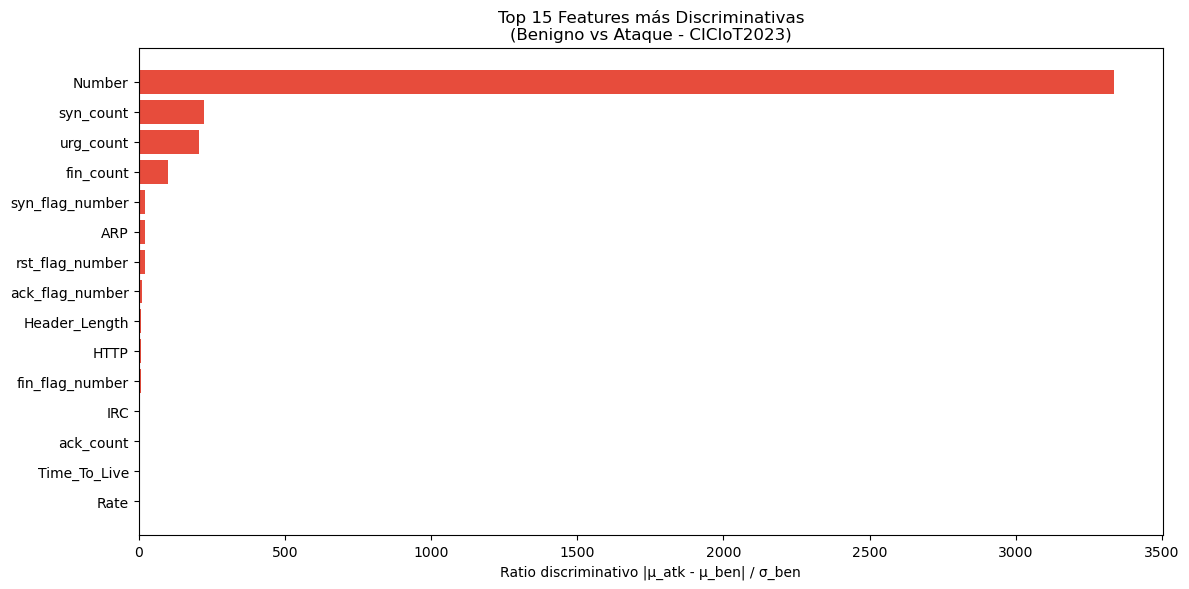

Guardada: features_discriminativas.png

Features con varianza < 0.01 en benigno (19):
SSH                4.539561e-07
cwr_flag_number    1.145546e-06
ICMP               1.572309e-06
ece_flag_number    2.426817e-06
UDP                1.294978e-05
rst_flag_number    1.942933e-05
DNS                2.556161e-05
ARP                5.228218e-05
fin_flag_number    6.847128e-05
syn_flag_number    8.233156e-05
IPv                1.889883e-04
DHCP               1.889883e-04
LLC                1.889883e-04
HTTPS              3.260256e-04
Number             6.471028e-04
rst_count          1.939044e-03
urg_count          1.942395e-03
fin_count          6.842527e-03
syn_count          8.229960e-03
dtype: float32

RESUMEN PARA LA TESIS
Features altamente discriminativas (ratio > 2): 22
Features moderadamente discriminativas (0.5-2): 9
Features poco discriminativas (< 0.5): 6

Top 5 más discriminativas: ['Number', 'syn_count', 'urg_count', 'fin_count', 'syn_flag_number']
Top 5 menos discriminativas: 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── CONFIGURACIÓN ─────────────────────────────────────────────────────────────
# Ajusta estas rutas a donde tienes tus archivos
TRAIN_PATH = r"C:\Users\Daniel\ventanas\train_w20.npy"
ATK_PATH   = r"C:\Users\Daniel\ventanas\atk_w20.npy"
LABELS_PATH = r"C:\Users\Daniel\ventanas\atk_labels_w20.npy"

FEATURES = [
    'Header_Length', 'Protocol_Type', 'Time_To_Live', 'Rate',
    'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
    'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
    'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count',
    'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'SSH',
    'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC',
    'Tot_sum', 'Min', 'Max', 'AVG', 'Std', 'Tot_size',
    'IAT', 'Number', 'Variance'
]

# ── CARGA ─────────────────────────────────────────────────────────────────────
train = np.load(TRAIN_PATH)   # (43925, 20, 37)
atk   = np.load(ATK_PATH)     # (10980, 20, 37)
labels = np.load(LABELS_PATH) # (10980,)

# Aplanar: tomar el promedio temporal de cada ventana → (N, 37)
train_flat = train.mean(axis=1)
atk_flat   = atk.mean(axis=1)

df_train = pd.DataFrame(train_flat, columns=FEATURES)
df_atk   = pd.DataFrame(atk_flat,   columns=FEATURES)

print("Train shape:", df_train.shape)
print("Atk shape:  ", df_atk.shape)

# ── 1. VARIANZA POR FEATURE EN TRÁFICO BENIGNO ────────────────────────────────
# Qué tanto varía cada feature en el tráfico normal
var_train = df_train.var().sort_values(ascending=False)
print("\nTop 10 features con más varianza en benigno:")
print(var_train.head(10))

# ── 2. DIFERENCIA DE MEDIAS: BENIGNO VS ATAQUE ────────────────────────────────
# Qué features cambian más entre benigno y ataque
diff_means = (df_atk.mean() - df_train.mean()).abs().sort_values(ascending=False)
print("\nTop 10 features con mayor diferencia de medias (benigno vs ataque):")
print(diff_means.head(10))

# ── 3. RATIO DE SEPARACIÓN (separabilidad) ────────────────────────────────────
# Versión simple: |media_atk - media_ben| / (std_ben + 1e-8)
ratio = ((df_atk.mean() - df_train.mean()).abs() / 
         (df_train.std() + 1e-8)).sort_values(ascending=False)
print("\nTop 10 features más discriminativas (ratio señal/ruido):")
print(ratio.head(10))

# ── 4. GRÁFICA: TOP 15 FEATURES MÁS DISCRIMINATIVAS ──────────────────────────
top15 = ratio.head(15)
colors = ['#e74c3c' if v > 2 else '#f39c12' if v > 0.5 else '#2ecc71' 
          for v in top15.values]

plt.figure(figsize=(12, 6))
bars = plt.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
plt.xlabel('Ratio discriminativo |μ_atk - μ_ben| / σ_ben')
plt.title('Top 15 Features más Discriminativas\n(Benigno vs Ataque - CICIoT2023)')
plt.tight_layout()
plt.savefig('features_discriminativas.png', dpi=150)
plt.show()
print("Guardada: features_discriminativas.png")

# ── 5. FEATURES CON VARIANZA CASI CERO EN BENIGNO ────────────────────────────
# Estas son las que el LSTM-AE aprende como "constantes"
low_var = df_train.var()[df_train.var() < 0.01]
print(f"\nFeatures con varianza < 0.01 en benigno ({len(low_var)}):")
print(low_var.sort_values())

# ── 6. RESUMEN FINAL ──────────────────────────────────────────────────────────
print("\n" + "="*60)
print("RESUMEN PARA LA TESIS")
print("="*60)
print(f"Features altamente discriminativas (ratio > 2): "
      f"{(ratio > 2).sum()}")
print(f"Features moderadamente discriminativas (0.5-2): "
      f"{((ratio > 0.5) & (ratio <= 2)).sum()}")
print(f"Features poco discriminativas (< 0.5): "
      f"{(ratio <= 0.5).sum()}")
print(f"\nTop 5 más discriminativas: {list(ratio.head(5).index)}")
print(f"Top 5 menos discriminativas: {list(ratio.tail(5).index)}")